In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, kruskal, f_oneway, mannwhitneyu
from sklearn.feature_selection import mutual_info_classif, SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Set professional styling
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## 2. LOAD DATASET

In [52]:
df=pd.read_csv("D:\ML\Projects\EDA-of-pregnancy-risk-prediction-dataset\Dataset\Processed Data\pregnancy_risk_prediction_cleaned.csv")
print(f"Dataset Shape: {df.shape}")
print(f"Memory Usage: {df.memory_usage().sum() / 1024**2:.2f} MB")

Dataset Shape: (5313, 17)
Memory Usage: 0.69 MB


In [55]:
# Few rows of the dataset to understand its structure
df.sample(5)

,umur,paritas,jarak_anak,jarak_anak_cat,tb,hb,lila,hbsag,hiv,dm,ht,protein,diastole,sistole,perdarahan,penyakit_lain_cat,risiko_cat
886,28,2,48.0,1,157.0,12.6,28.0,2,2,2,2,2,110,80,2,0,0
1590,28,2,48.0,1,152.0,9.2,24.0,2,2,2,2,2,120,80,2,0,1
651,33,0,999.0,0,151.0,15.1,23.5,2,2,2,2,2,130,80,2,0,0
2200,28,1,38.0,1,151.0,12.0,36.0,2,2,2,2,2,110,70,2,0,0
163,35,2,120.0,3,148.0,11.1,24.5,2,2,2,2,2,100,70,2,0,2


In [58]:
# Create comprehensive data quality report
quality_report = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values,
    'Non-Null Count': df.count().values,
    'Null Count': df.isnull().sum().values,
    'Null %': (df.isnull().sum() / len(df) * 100).values,
    'Unique Values': df.nunique().values,
    'Min': df.min().values,
    'Max': df.max().values,
    'Mean': df.mean().values,
})


print("***** DATA QUALITY REPORT *****")

display(quality_report)

# Check for duplicates
print(f"\nDuplicate Rows: {df.duplicated().sum()}")
print(f"Duplicate Rows (all columns): {df.duplicated(keep=False).sum()}")

***** DATA QUALITY REPORT *****


,Column,Data Type,Non-Null Count,Null Count,Null %,Unique Values,Min,Max,Mean
0,umur,int64,5313,0,0.0,35,12.0,51.0,27.641446
1,paritas,int64,5313,0,0.0,10,0.0,33.0,1.720873
2,jarak_anak,float64,5313,0,0.0,90,0.0,999.0,425.450894
3,jarak_anak_cat,int64,5313,0,0.0,4,0.0,3.0,1.069076
4,tb,float64,5313,0,0.0,156,15.0,1590.0,152.404047
5,hb,float64,5313,0,0.0,89,0.0,144.1,11.922007
6,lila,float64,5313,0,0.0,133,0.0,2426.0,25.976539
7,hbsag,int64,5313,0,0.0,2,1.0,2.0,1.995859
8,hiv,int64,5313,0,0.0,2,1.0,2.0,1.999435
9,dm,int64,5313,0,0.0,2,1.0,2.0,1.999624



Duplicate Rows: 155
Duplicate Rows (all columns): 310


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
umur,5313.0,27.641446,6.222287,12.0,23.0,27.0,32.0,51.0
paritas,5313.0,1.720873,1.347343,0.0,1.0,2.0,2.0,33.0
jarak_anak,5313.0,425.450894,455.084319,0.0,48.0,96.0,999.0,999.0
jarak_anak_cat,5313.0,1.069076,1.008403,0.0,0.0,1.0,2.0,3.0
tb,5313.0,152.404047,20.650068,15.0,150.0,151.5,155.0,1590.0
hb,5313.0,11.922007,3.038624,0.0,11.0,11.8,12.5,144.1
lila,5313.0,25.976539,33.096832,0.0,24.0,25.0,27.0,2426.0
hbsag,5313.0,1.995859,0.064222,1.0,2.0,2.0,2.0,2.0
hiv,5313.0,1.999435,0.023758,1.0,2.0,2.0,2.0,2.0
dm,5313.0,1.999624,0.019400,1.0,2.0,2.0,2.0,2.0


In [65]:
# Missing values summary
missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': df.isnull().sum().values,
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2).values
})

display(missing_summary[missing_summary['Missing Count'] > 0] if missing_summary['Missing Count'].sum() > 0 
        else pd.DataFrame({'Status': ['No missing values detected']}))

# Visualize missing data
if df.isnull().sum().sum() > 0:
    fig, ax = plt.subplots(figsize=(12, 4))
    sns.heatmap(df.isnull(), cbar=False, cmap='viridis', ax=ax)
    plt.title('Missing Data Heatmap', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values detected in the dataset")

,Status
0,No missing values detected


No missing values detected in the dataset


### FEATURE CLASSIFICATION

In [76]:
def detect_columns(df, drop_column="risiko_cat"):
    # Create a list of columns to consider, excluding the drop_column if provided
    cols_to_consider = [col for col in df.columns if col != drop_column]
    df_filtered = df[cols_to_consider]

    binary_cols = [c for c in df_filtered.columns if df_filtered[c].nunique() == 2]
    numeric_cols = df_filtered.select_dtypes(
        include=["int64", "float64", "int32", "float32"]
    ).columns.tolist()
    categorical_cols = df_filtered.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    # Remove binary cols from numeric/categorical to avoid duplication
    numeric_cols     = [c for c in numeric_cols     if c not in binary_cols]
    categorical_cols = [c for c in categorical_cols if c not in binary_cols]

    return numeric_cols, categorical_cols, binary_cols

In [81]:
numeric_cols, categorical_cols, binary_cols = detect_columns(df)
print(f"\nNumerical Features ({len(numeric_cols)}): {numeric_cols}")
print(f"\nBinary Features ({len(binary_cols)}): {binary_cols}")
print(f"\nCategorical Features ({len(categorical_cols)}): {categorical_cols}")


Numerical Features (10): ['umur', 'paritas', 'jarak_anak', 'jarak_anak_cat', 'tb', 'hb', 'lila', 'diastole', 'sistole', 'perdarahan']

Binary Features (6): ['hbsag', 'hiv', 'dm', 'ht', 'protein', 'penyakit_lain_cat']

Categorical Features (0): []


### TARGET COLUMN ANALYSIS

,Risk Level,Count,Percentage
0,0,3491,65.71
1,1,1464,27.56
2,2,299,5.63
3,3,59,1.11



Imbalance Ratio (Max/Min): 59.17x
Majority Class: 0 (3491 samples)
Minority Class: 3 (59 samples)


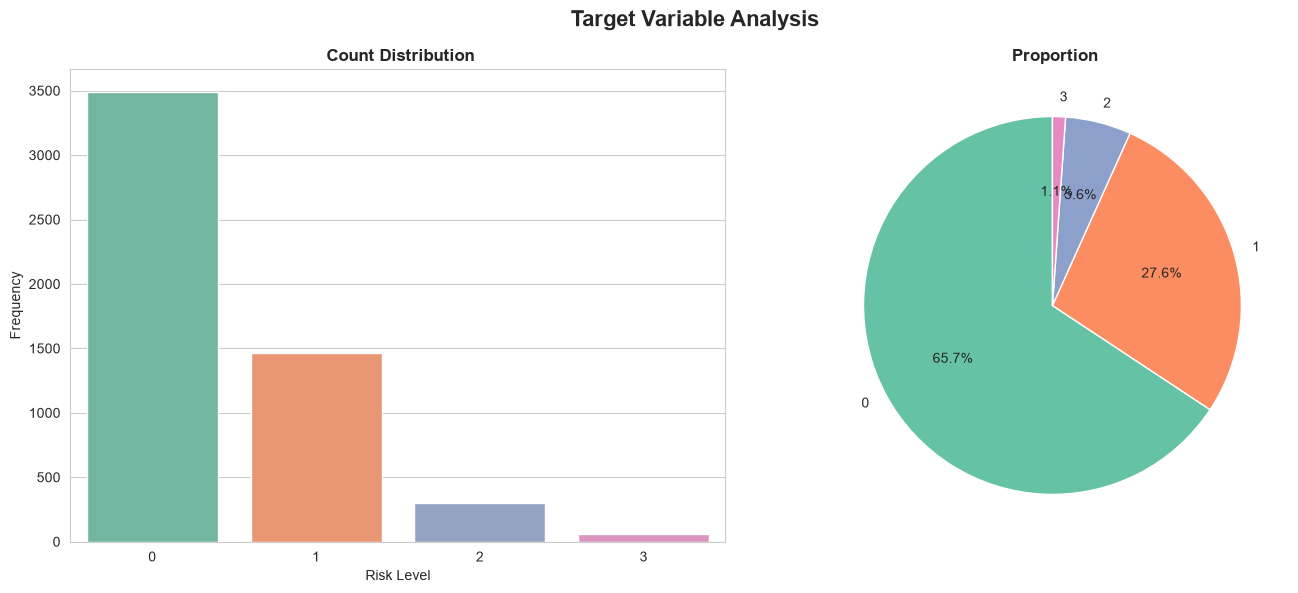

In [94]:
# Target variable distribution
target_col = "risiko_cat"
target_counts = df[target_col].value_counts().sort_index()
target_pct = df[target_col].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    'Risk Level': target_counts.index,
    'Count': target_counts.values,
    'Percentage': target_pct.values.round(2)
})

display(target_summary)
# Visualize target
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Imbalance ratio
print(f"\nImbalance Ratio (Max/Min): {target_counts.max() / target_counts.min():.2f}x")
print(f"Majority Class: {target_counts.idxmax()} ({target_counts.max()} samples)")
print(f"Minority Class: {target_counts.idxmin()} ({target_counts.min()} samples)")

# Count plot
sns.countplot(data=df, x=target_col, ax=axes[0], palette='Set2')
axes[0].set_title(' Count Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency')
axes[0].set_xlabel('Risk Level')

# Pie chart
colors = sns.color_palette('Set2', len(target_counts))
axes[1].pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[1].set_title(' Proportion', fontsize=12, fontweight='bold')

fig.suptitle("Target Variable Analysis", fontsize=16, fontweight="bold")
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# univariate analysis

In [205]:
name={
    "umur": "Age of the pregnant woman",
    "sistole": "Systolic Blood Pressure",
    "diastole": "Diastolic Blood Pressure",
    "paritas": "Number of previous births",
    "jarak_anak": "Birth spacing(months)",
    "tb": "Body Height (cm)",
    "perdarahan": "Bleeding Presence",
    "hb": "Hemoglobin level (g/dL)",
    "lila": "Mid upper arm circumference",
        'hbsag': 'Hepatitis B Surface Antigen (HBsAg) Test',
    'hiv': 'Human Immunodeficiency Virus (HIV) Test',
    'dm': 'Diabetes Mellitus Presence',
    'ht': 'Hypertension Presence',
    'protein': 'Proteinuria Presence',
    'penyakit_lain_cat': 'Other Diseases Presence'
}

In [211]:
def plot_numerical_distribution(df, col, figsize=(14, 6)):
    """Plot histogram, KDE, and boxplot for numerical features"""
    
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    # Histogram + KDE
    axes[0].hist(df[col], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    ax2 = axes[0].twinx()
    df[col].plot(kind='kde', ax=ax2, color='red', linewidth=1)
    axes[0].set_title(f'{col} - Distribution', fontweight='bold')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')
    ax2.set_ylabel('Density')
    
    # Boxplot
    sns.boxplot(data=df, y=col, ax=axes[1], color='lightblue',hue="risiko_cat")
    axes[1].set_title(f'{col} - Boxplot', fontweight='bold')
    axes[1].set_ylabel(col)
    
    # Violin plot
    sns.violinplot(data=df, y=col, ax=axes[2], color='lightgreen',hue="risiko_cat")
    axes[2].set_title(f'{col} - Violin Plot', fontweight='bold')
    axes[2].set_ylabel(col)
    
    plt.suptitle(f"{col}: {name.get(col, col)}  | Skewness: {round(df[col].skew(), 2)}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
def plot_categorical_distribution(df, col, figsize=(14, 5)):
    """Plot count and percentage for categorical features"""
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    counts = df[col].value_counts()
    pct = df[col].value_counts(normalize=True) * 100
    
    # Count plot
    sns.countplot(data=df, x=col, ax=axes[0], palette='Set2', order=counts.index,hue="risiko_cat")
    axes[0].set_title(f'{col} - Count Distribution', fontweight='bold')
    axes[0].set_ylabel('Frequency')
    
    # Percentage bar
    sns.countplot(data=df, x=col, ax=axes[1], palette='Set2', order=pct.index, hue="risiko_cat")
    axes[1].set_xticks(range(len(pct)))
    axes[1].set_xticklabels(pct.index)
    axes[1].set_title(f'{col} - Percentage Distribution', fontweight='bold')
    axes[1].set_ylabel('Percentage (%)')
    
    # Add percentage labels
    for i, v in enumerate(pct.values):
        axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
    
    plt.suptitle(f"{col}: {name.get(col, col)}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

def calculate_distribution_stats(df, col):
    """Calculate distribution statistics"""
    
    stats_dict = {
        'Mean': df[col].mean(),
        'Median': df[col].median(),
        'Mode': df[col].mode().values[0] if len(df[col].mode()) > 0 else np.nan,
        'Std Dev': df[col].std(),
        'Skewness': df[col].skew(),
        'Kurtosis': df[col].kurtosis(),
        'Min': df[col].min(),
        'Max': df[col].max(),
        'Q1': df[col].quantile(0.25),
        'Q3': df[col].quantile(0.75),
        'IQR': df[col].quantile(0.75) - df[col].quantile(0.25)
    }
    
    return pd.Series(stats_dict)

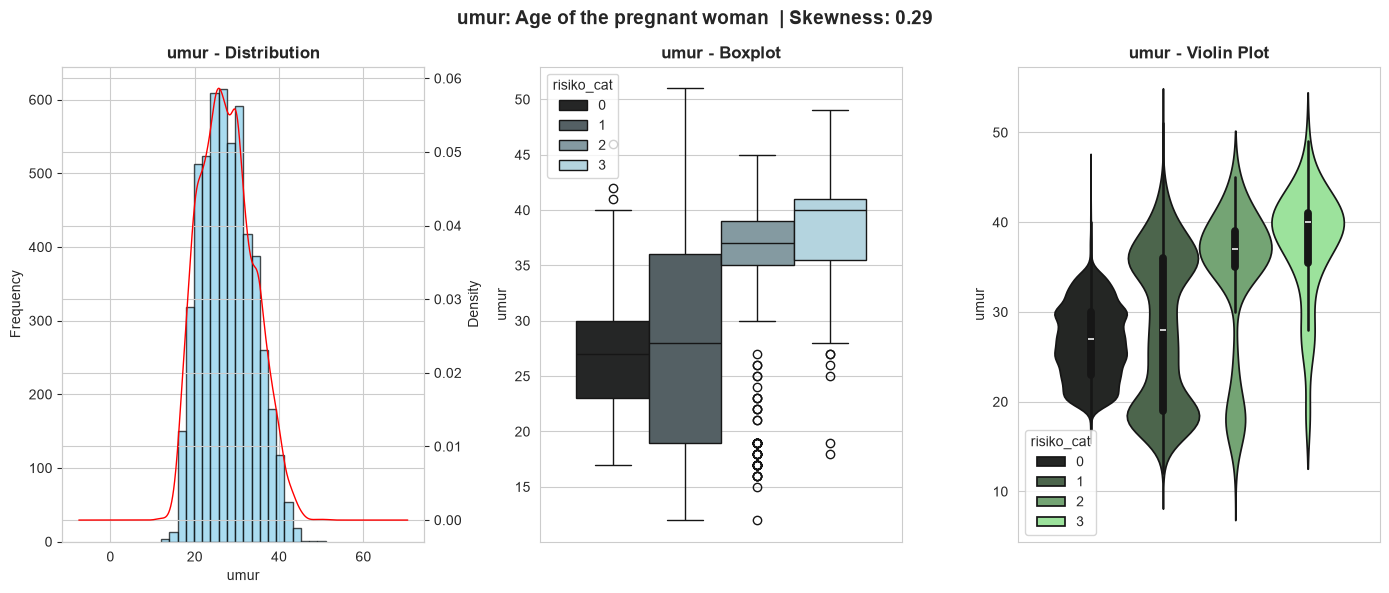

In [187]:
plot_numerical_distribution(df, 'umur')


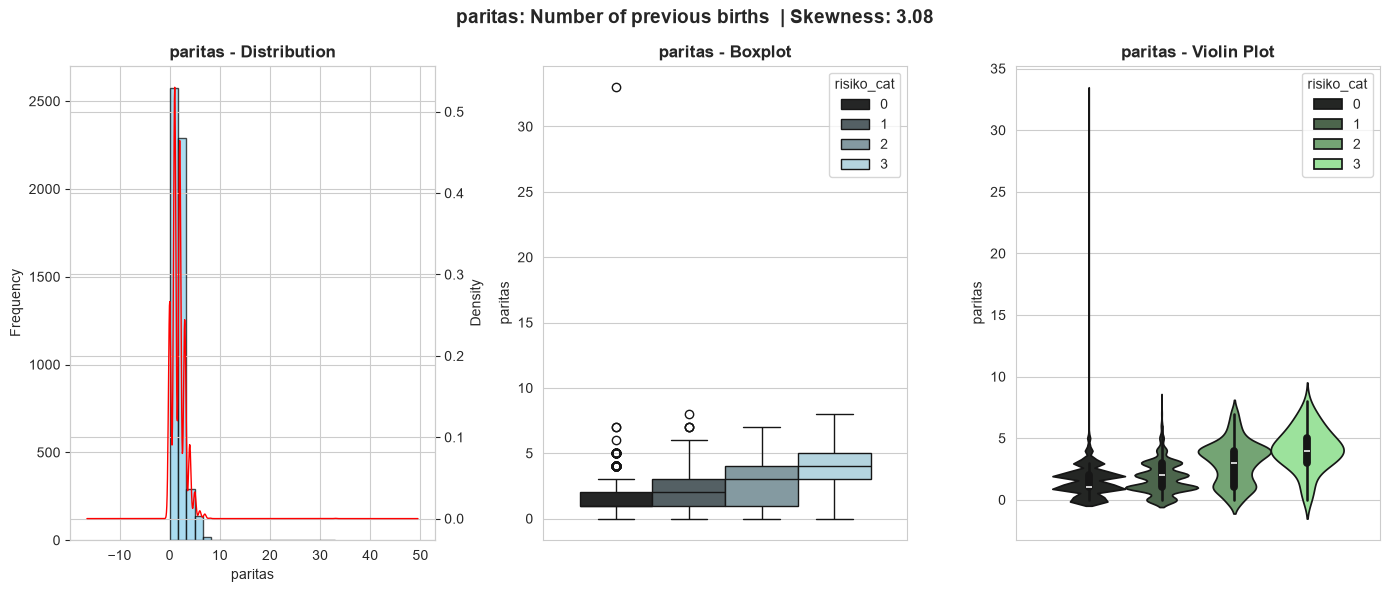

,umur,paritas,jarak_anak,jarak_anak_cat,tb,hb,lila,hbsag,hiv,dm,ht,protein,diastole,sistole,perdarahan,penyakit_lain_cat,risiko_cat
2145,31,33,999.0,0,150.0,12.2,25.0,2,2,2,2,2,130,90,2,0,0


In [188]:
plot_numerical_distribution(df, 'paritas')
display(df[df["paritas"]>10])

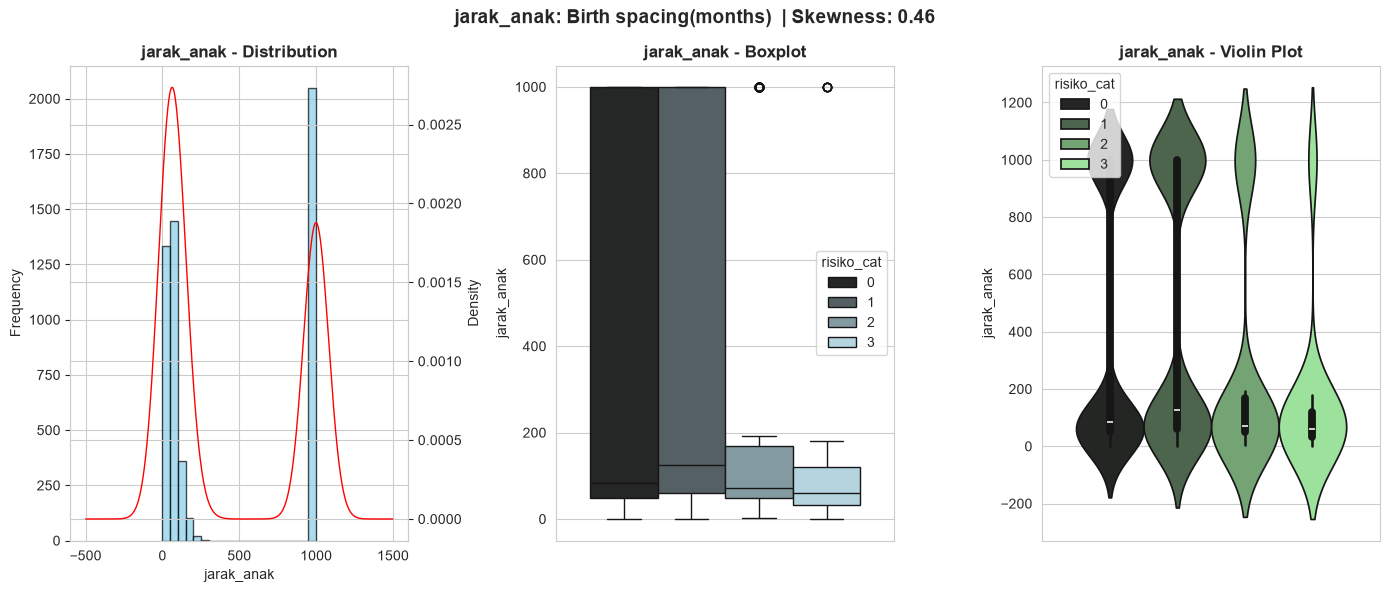

In [189]:
plot_numerical_distribution(df, 'jarak_anak')

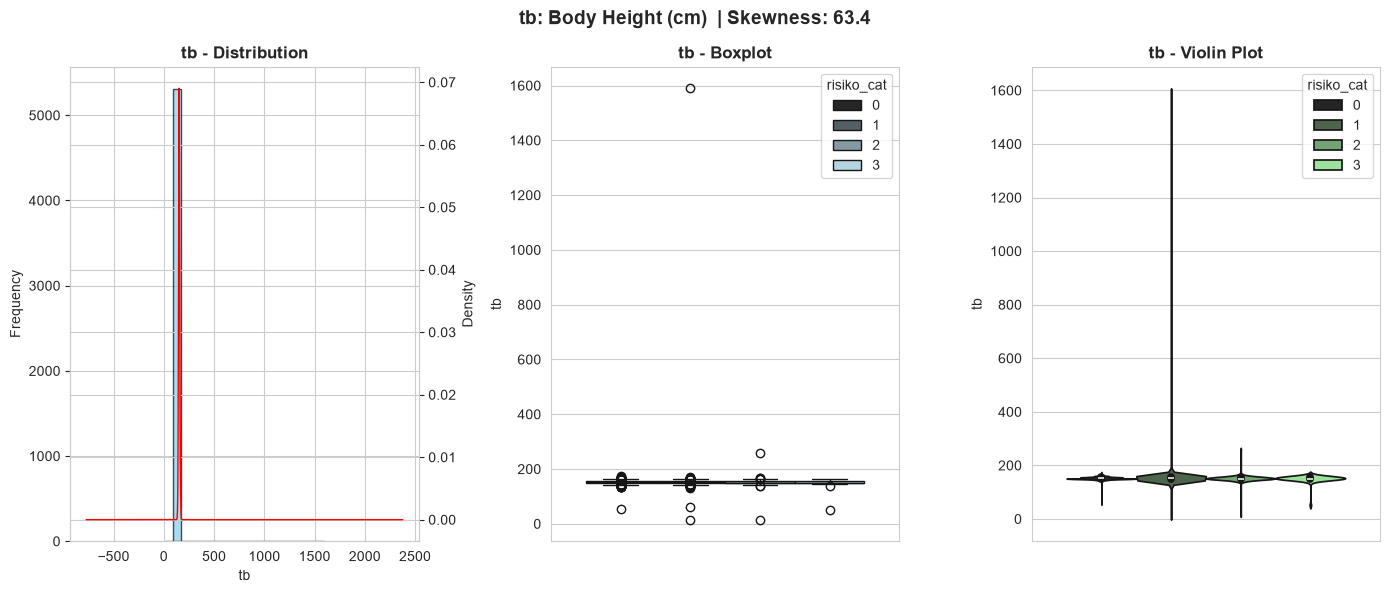

,umur,paritas,jarak_anak,jarak_anak_cat,tb,hb,lila,hbsag,hiv,dm,ht,protein,diastole,sistole,perdarahan,penyakit_lain_cat,risiko_cat
1842,35,3,24.0,1,15.0,11.0,25.0,2,2,2,2,2,120,80,2,0,1
1901,17,1,999.0,0,60.0,11.9,18.5,2,2,2,2,2,120,80,2,0,1
1905,36,4,41.0,1,52.0,10.3,26.0,2,2,2,2,2,120,80,2,0,3
2490,25,2,27.0,1,55.0,12.9,23.7,2,2,2,2,2,110,80,2,0,0
3167,35,3,36.0,1,15.0,13.5,28.0,2,2,2,2,2,110,70,2,0,2
3445,37,2,36.0,1,1590.0,11.8,30.0,2,2,2,2,2,90,60,2,0,1
4949,27,4,41.0,1,173.0,12.5,26.0,2,2,2,2,2,120,80,2,0,0
5124,34,4,108.0,3,258.0,9.3,28.0,2,2,2,2,2,110,80,2,0,2


In [190]:
plot_numerical_distribution(df, 'tb')
display(df[(df["tb"]<130) | (df["tb"]>170)])

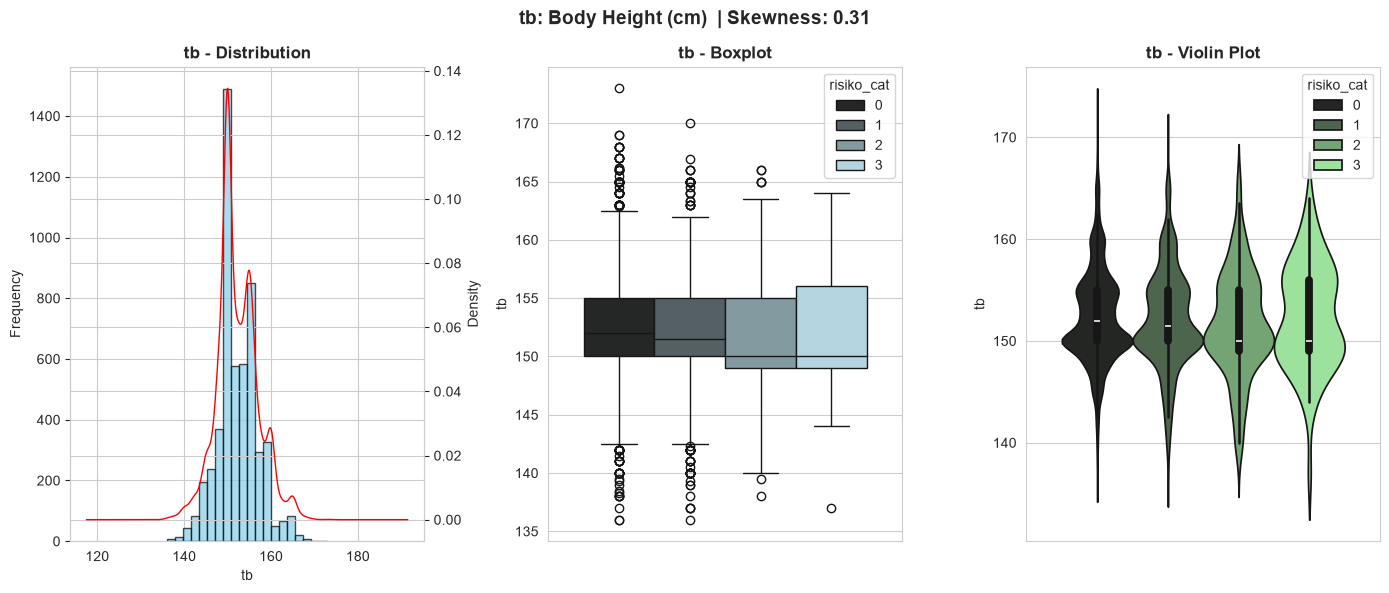

In [191]:
plot_numerical_distribution(df[(df["tb"] < 180) & (df['tb'] > 135)], col='tb')

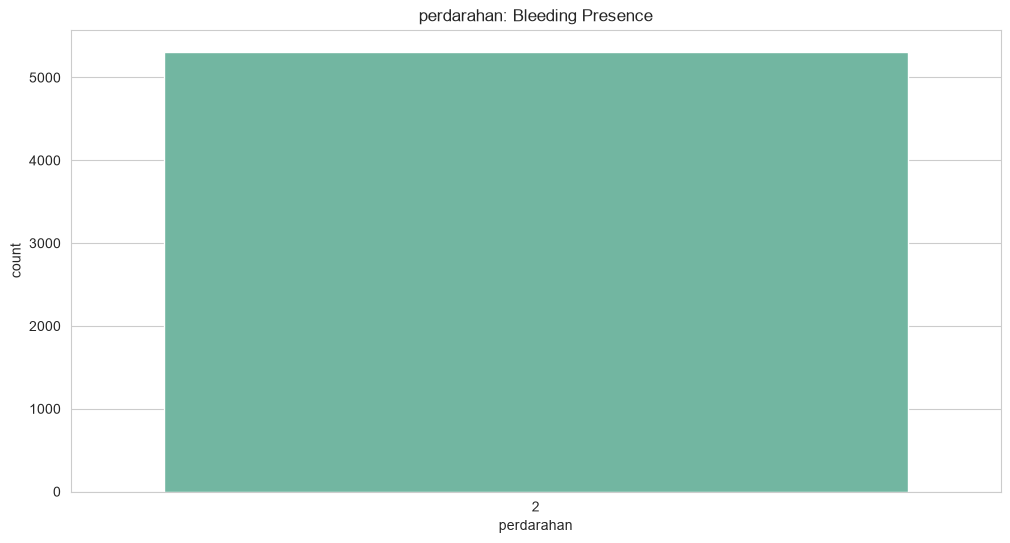

perdarahan
2    100.0
Name: proportion, dtype: float64


In [192]:
sns.countplot(data=df, x='perdarahan', order=df['perdarahan'].value_counts().index, palette='Set2'  )
plt.title("perdarahan: Bleeding Presence")
plt.show()
print(df['perdarahan'].value_counts(normalize=True) * 100)

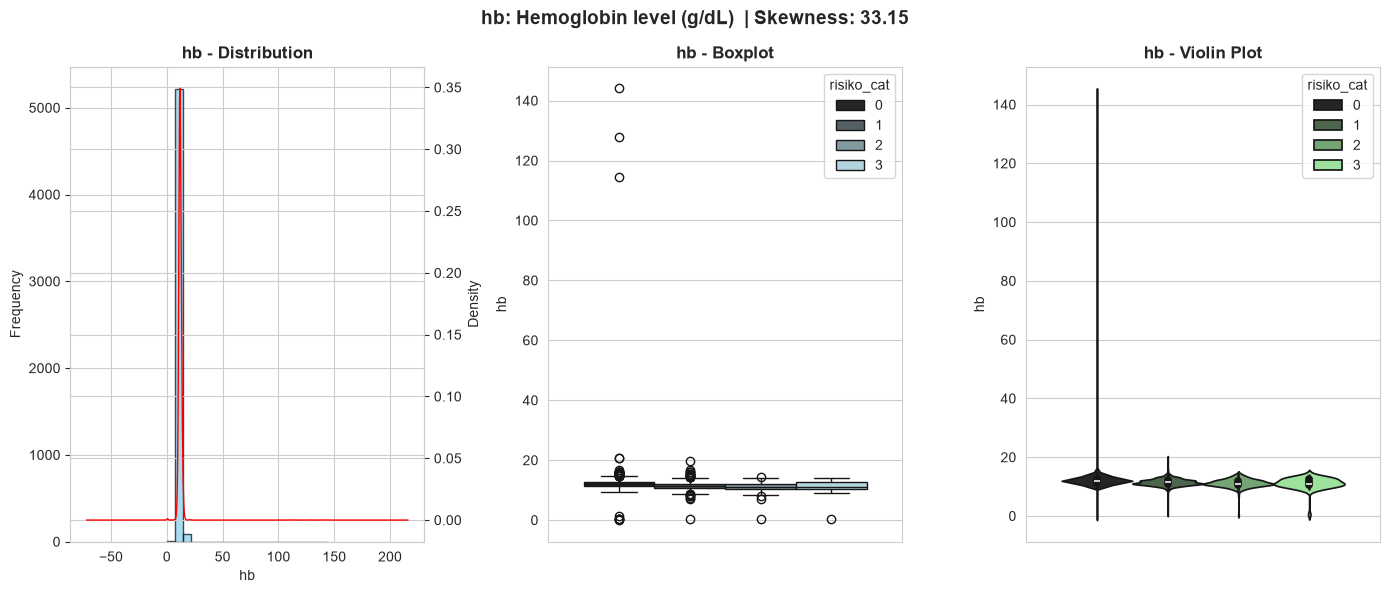

,umur,paritas,jarak_anak,jarak_anak_cat,tb,hb,lila,hbsag,hiv,dm,ht,protein,diastole,sistole,perdarahan,penyakit_lain_cat,risiko_cat
12,30,0,999.0,0,138.5,20.600000,26.5,2,2,2,2,2,120,80,2,0,0
406,27,1,72.0,2,160.5,144.100000,30.7,2,2,2,2,2,120,70,2,0,0
452,40,3,60.0,2,150.0,0.381250,28.0,2,2,2,2,2,110,70,2,0,2
573,37,2,78.0,2,147.6,19.800000,23.5,2,2,2,2,2,110,90,2,0,1
915,33,5,999.0,0,150.0,128.000000,27.0,1,2,2,2,2,110,60,2,0,0
1456,32,4,999.0,0,151.0,0.000000,28.0,2,2,2,2,2,130,80,2,0,0
2528,25,1,60.0,2,150.0,20.600000,30.0,2,2,2,2,2,100,70,2,0,0
2576,31,7,120.0,3,153.0,114.400000,26.0,2,2,2,2,2,100,60,2,0,0
2838,17,1,999.0,0,150.0,6.900000,24.0,2,2,2,2,2,110,70,2,0,2
2860,20,2,72.0,2,150.0,1.300000,29.0,2,2,2,2,2,100,70,2,0,0


In [193]:
plot_numerical_distribution(df, col='hb')
display(df[(df["hb"] > 18) |(df['hb']<7)])

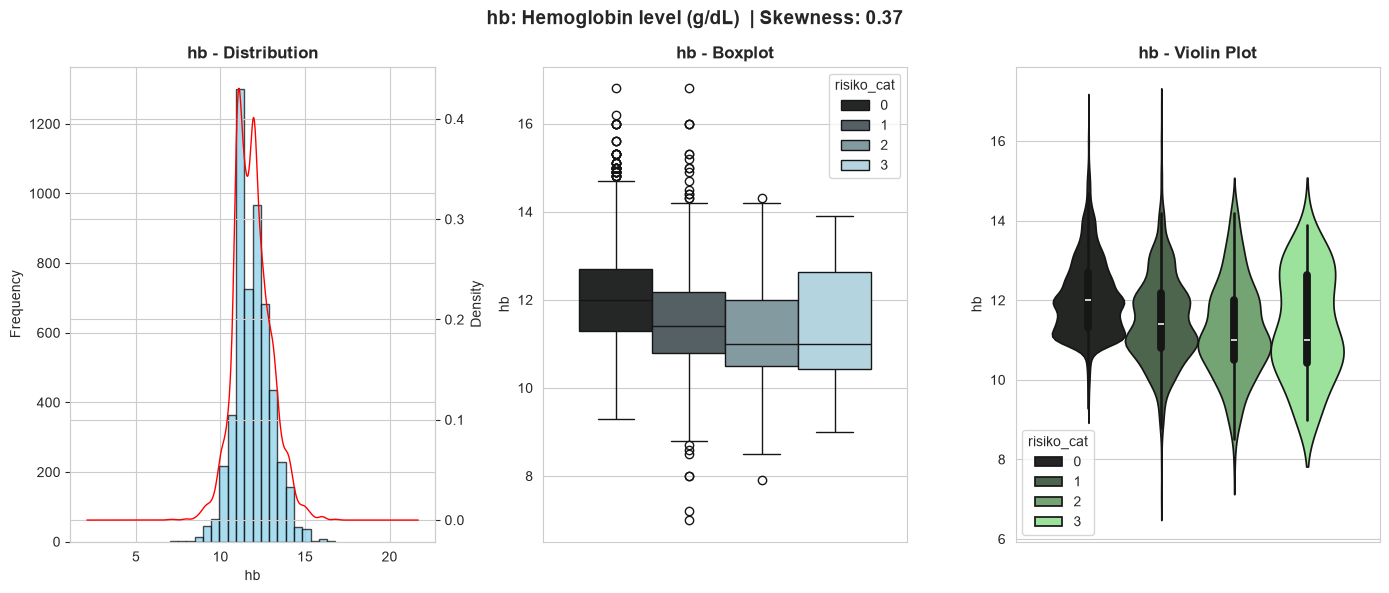

In [194]:
plot_numerical_distribution( df[(df["hb"] < 18) & (df['hb'] >= 7)], col='hb')

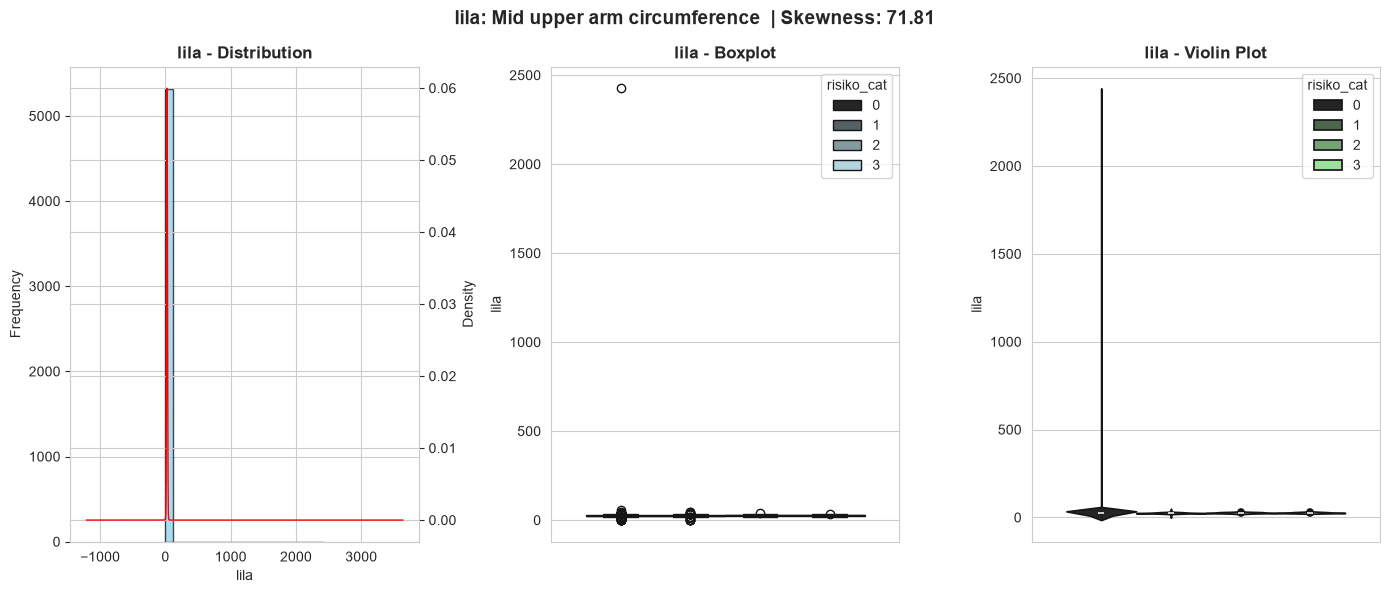

,umur,paritas,jarak_anak,jarak_anak_cat,tb,hb,lila,hbsag,hiv,dm,ht,protein,diastole,sistole,perdarahan,penyakit_lain_cat,risiko_cat
140,30,1,72.0,2,151.0,13.8,2.000000,2,2,2,2,2,120,80,2,0,0
1330,23,0,132.0,3,150.0,10.7,0.000000,1,2,2,2,2,120,80,2,0,1
1589,22,1,999.0,0,150.0,12.1,2.000000,2,2,2,2,2,120,70,2,0,0
1839,31,3,72.0,2,155.0,12.0,2426.000000,2,2,2,2,2,110,80,2,0,0
2250,20,0,999.0,0,150.0,10.9,0.920139,2,2,2,2,2,120,70,2,0,1
2264,19,1,60.0,2,145.0,12.8,0.961806,2,2,2,2,2,120,70,2,0,1
2268,25,1,84.0,2,149.0,11.9,0.920139,2,2,2,2,2,110,80,2,0,0
2403,25,1,24.0,1,152.0,13.1,0.961806,2,2,2,2,2,120,70,2,0,0
2413,20,0,999.0,0,150.0,13.8,0.961806,2,2,2,2,2,120,70,2,0,0
2440,22,0,999.0,0,150.0,13.4,0.961806,2,2,2,2,2,100,60,2,0,0


In [195]:
plot_numerical_distribution(df, col='lila')
display(df[(df["lila"] > 50) | (df['lila'] < 8)])

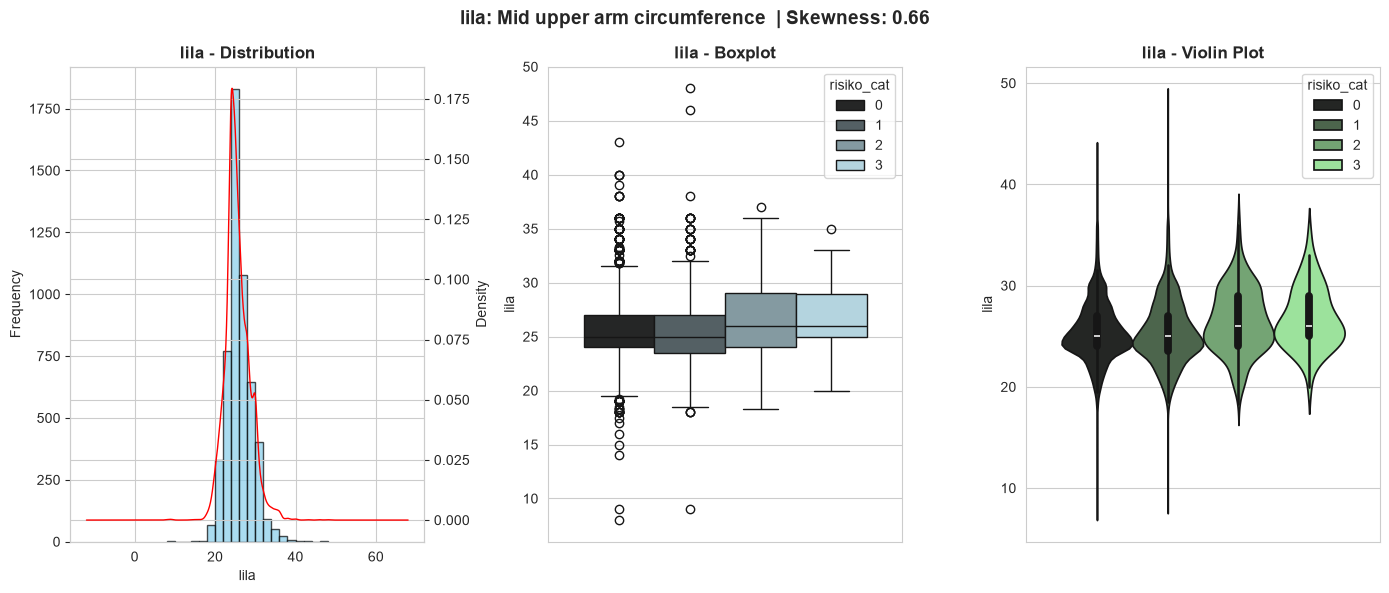

In [196]:
plot_numerical_distribution(df[(df["lila"] < 50) & (df['lila']>=8)], col='lila')

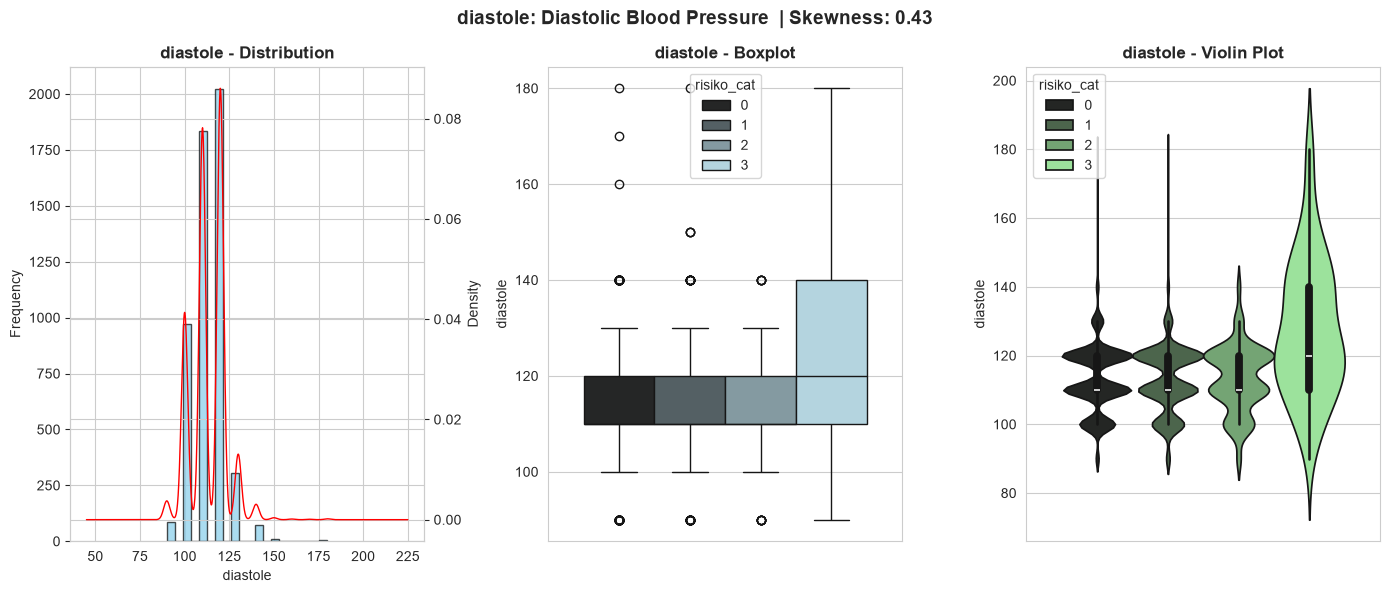

In [197]:
plot_numerical_distribution(df, 'diastole')   

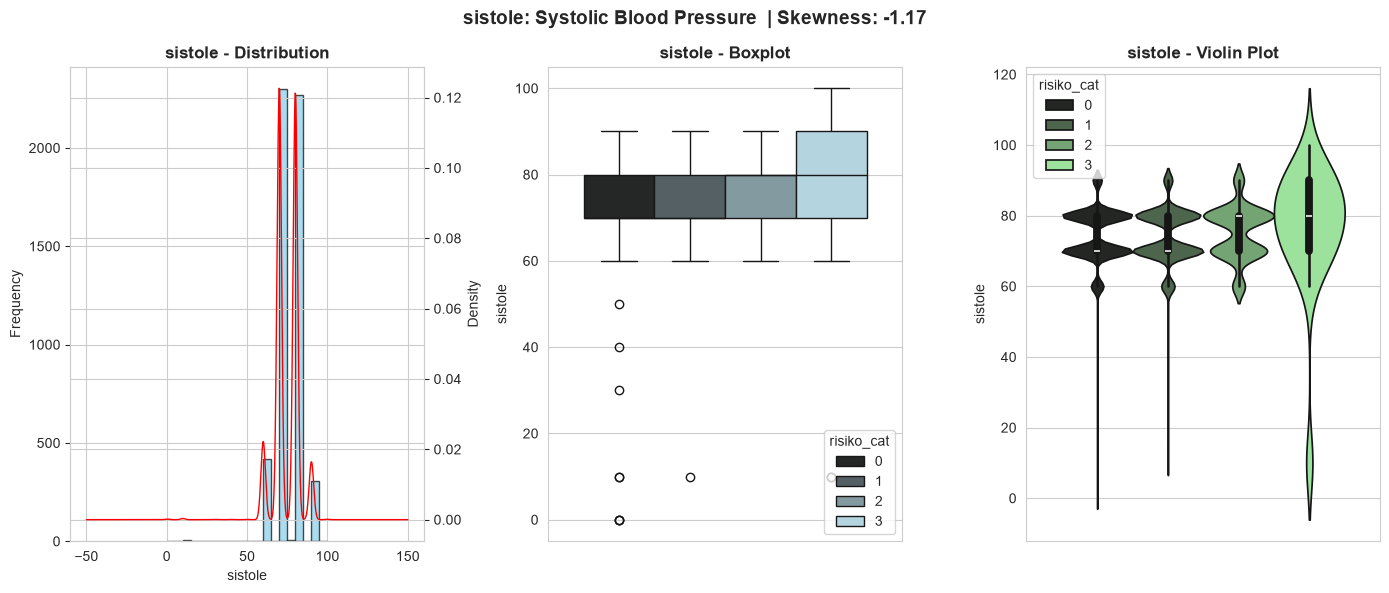

,umur,paritas,jarak_anak,jarak_anak_cat,tb,hb,lila,hbsag,hiv,dm,ht,protein,diastole,sistole,perdarahan,penyakit_lain_cat,risiko_cat
52,21,0,999.0,0,157.0,13.4,23.0,2,2,2,2,2,110,10,2,0,0
2249,27,1,84.0,2,155.0,11.2,24.0,2,2,2,2,1,170,0,2,0,0
2326,38,3,144.0,3,157.0,10.2,28.0,2,2,2,1,1,180,10,2,0,3
2342,39,4,132.0,3,157.0,12.4,30.0,2,2,2,1,1,180,10,2,0,3
2357,35,3,36.0,1,158.0,12.8,23.0,2,2,2,1,1,160,10,2,0,3
2447,21,1,12.0,1,148.0,14.3,21.0,2,2,2,2,2,180,10,2,0,0
2613,34,3,24.0,1,157.0,10.8,24.0,2,2,2,2,2,180,10,2,0,1
3925,31,3,60.0,2,149.0,11.0,24.0,2,2,2,2,2,140,0,2,0,0
4674,31,3,60.0,2,149.0,11.0,24.0,2,2,2,2,2,140,0,2,0,0


In [202]:
plot_numerical_distribution(df, 'sistole')   
display(df[(df['sistole'] <=20)])

In [31]:
binary_cols

['hbsag', 'hiv', 'dm', 'ht', 'protein', 'penyakit_lain_cat']

In [1]:
    # Cross-tabulation with target
    crosstab = pd.crosstab(df[col], df['risiko_cat'], margins=True)
    print(f"\nCross-tabulation with Target:")
    display(crosstab)
    
    # Chi-square test
    contingency = pd.crosstab(df[col], df['risiko_cat'])
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    
    print(f"\nChi-Square Test:")
    print(f"  • Chi-Square Statistic: {chi2:.4f}")
    print(f"  • P-value: {p_value:.6f}")
    print(f"  • Degrees of Freedom: {dof}")
    
    if p_value < 0.05:
        print(f"  ✓ Significant association with target (p < 0.05)")
    else:
        print(f"  ✗ No significant association with target (p ≥ 0.05)")


NameError: name 'pd' is not defined


BINARY FEATURES ANALYSIS

────────────────────────────────────────────────────────────────────────────────
Feature: HBSAG
────────────────────────────────────────────────────────────────────────────────


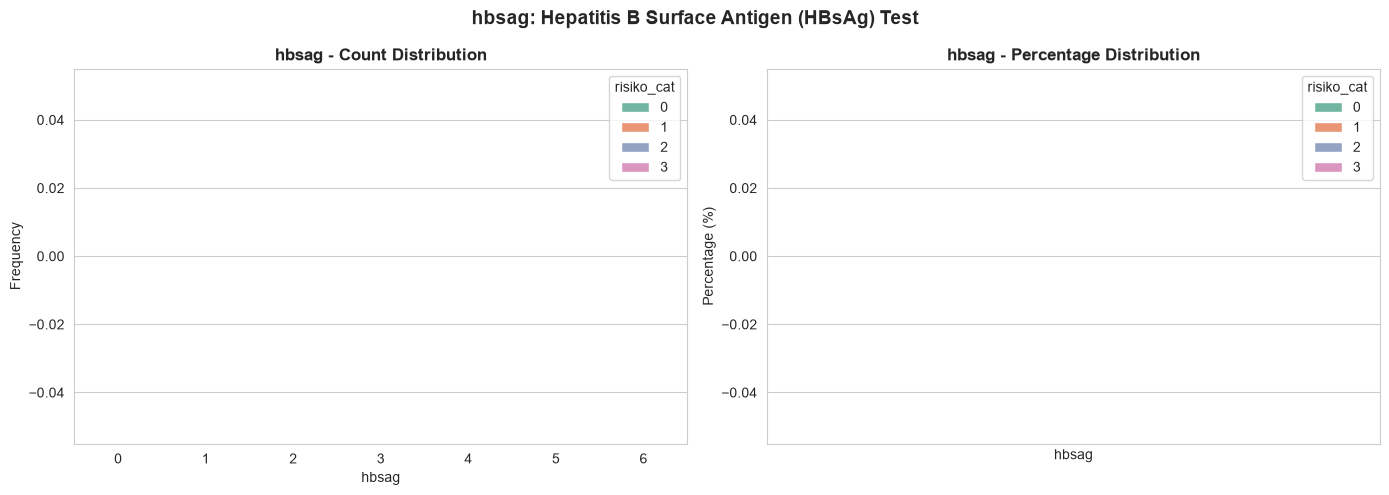


────────────────────────────────────────────────────────────────────────────────
Feature: HIV
────────────────────────────────────────────────────────────────────────────────


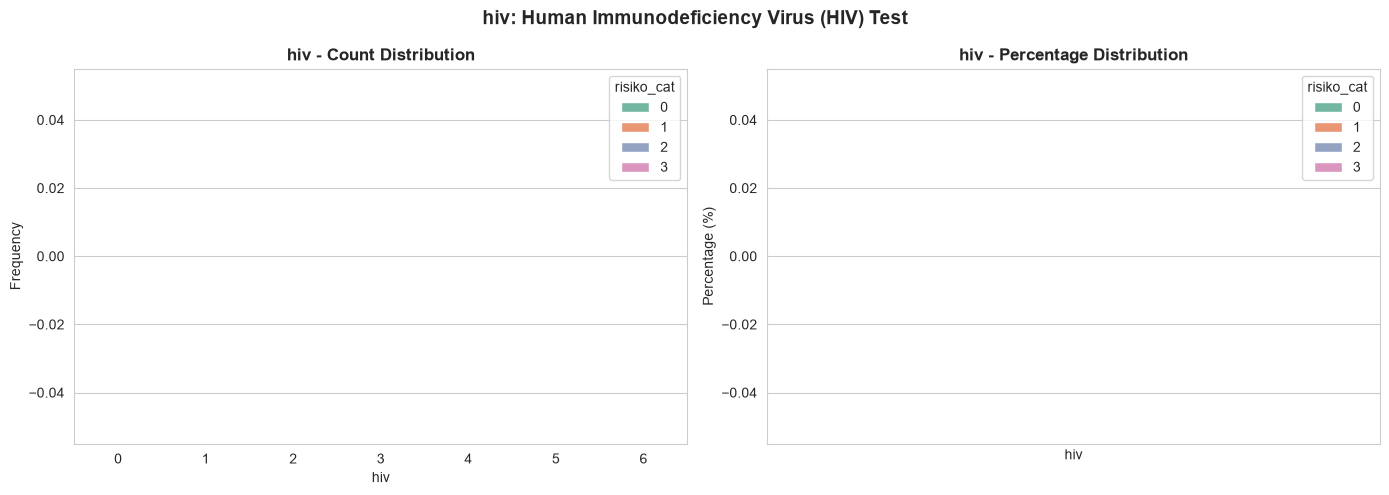


────────────────────────────────────────────────────────────────────────────────
Feature: DM
────────────────────────────────────────────────────────────────────────────────


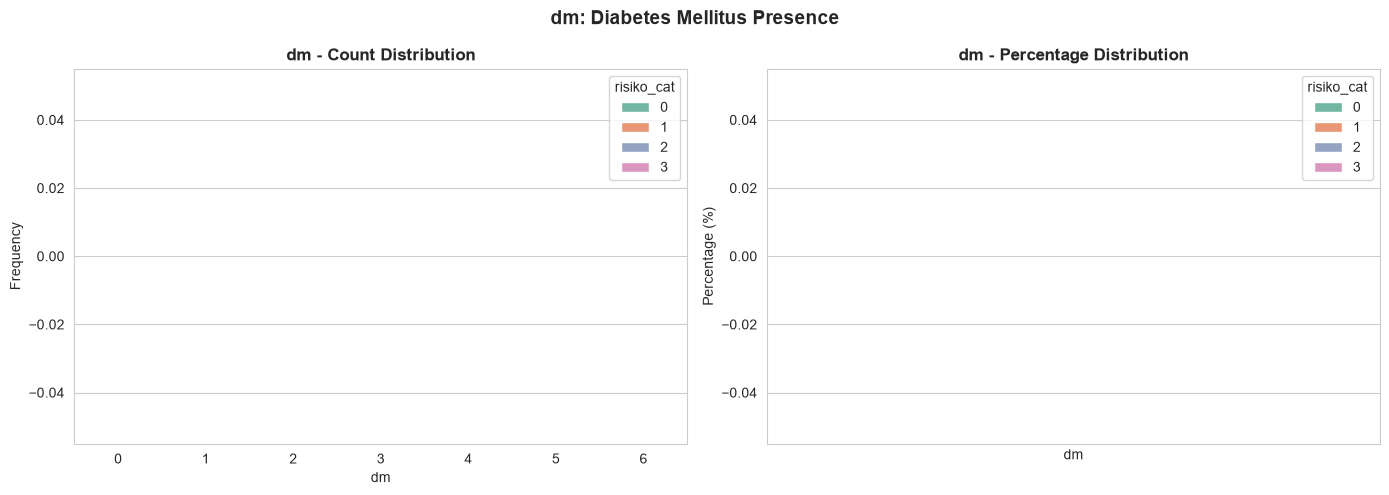


────────────────────────────────────────────────────────────────────────────────
Feature: HT
────────────────────────────────────────────────────────────────────────────────


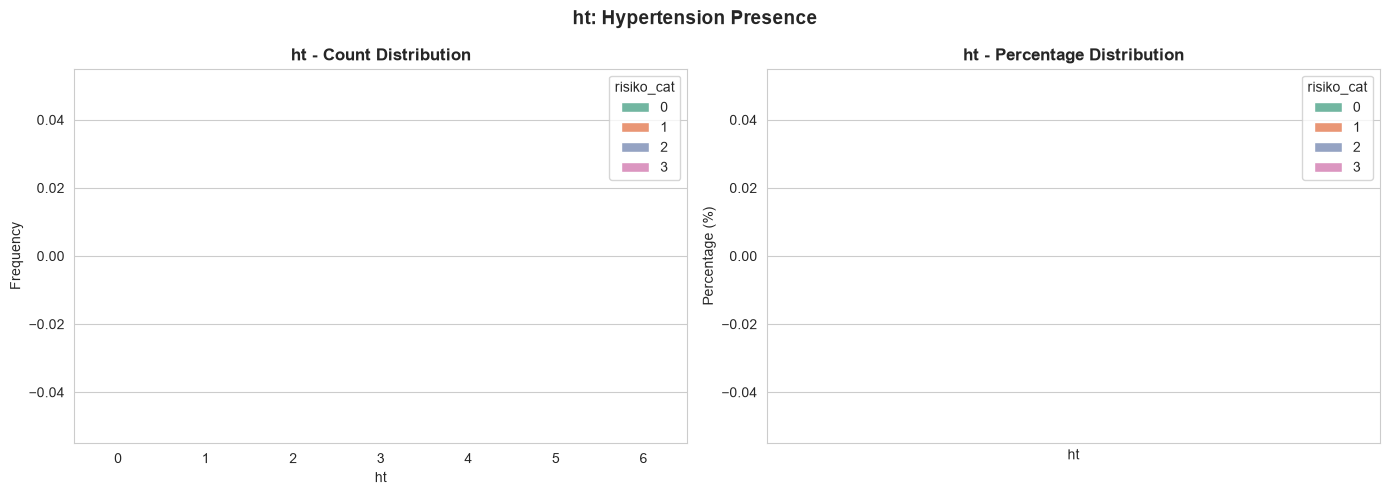


────────────────────────────────────────────────────────────────────────────────
Feature: PROTEIN
────────────────────────────────────────────────────────────────────────────────


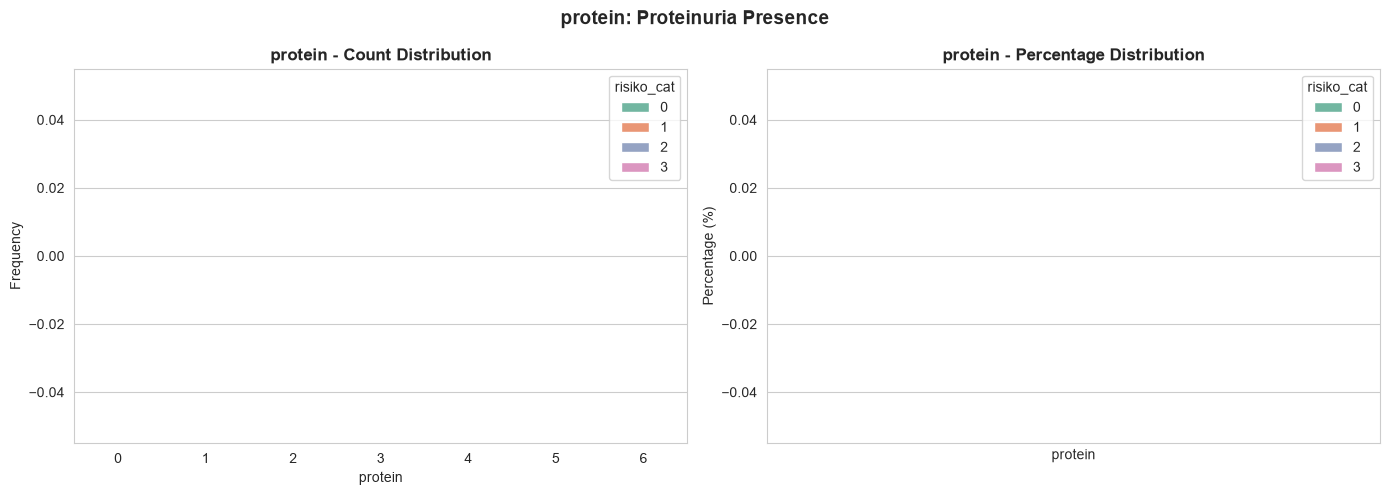


────────────────────────────────────────────────────────────────────────────────
Feature: PENYAKIT_LAIN_CAT
────────────────────────────────────────────────────────────────────────────────


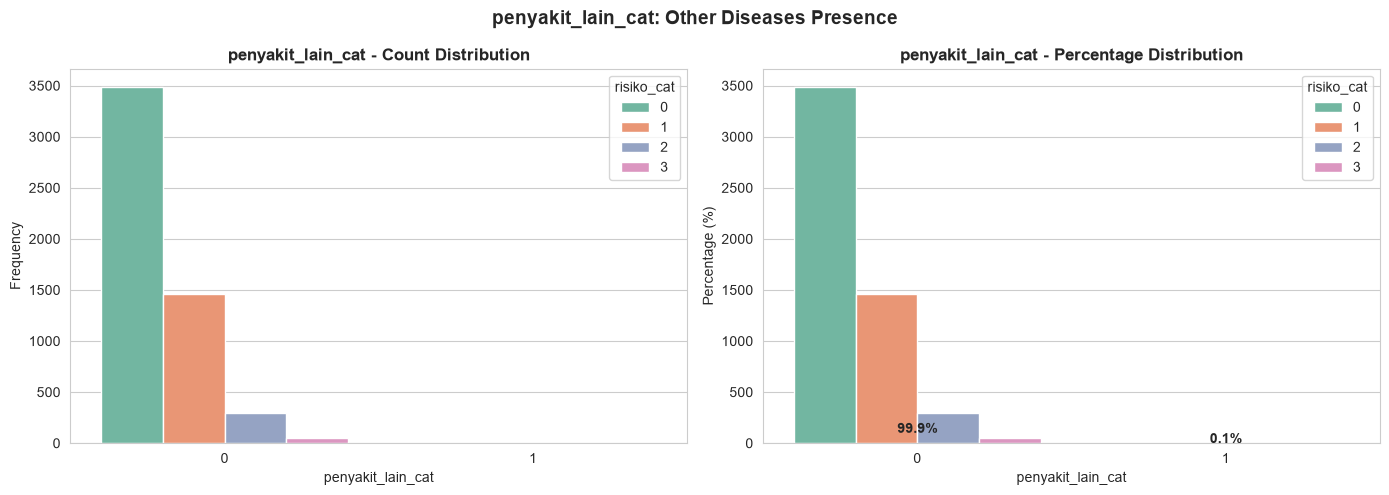

In [ ]:
print("\n" + "=" * 80)
print("BINARY FEATURES ANALYSIS")
print("=" * 80)


for col in binary_cols:
    print(f"\n{'─' * 80}")
    print(f"Feature: {col.upper()}")
    print(f"{'─' * 80}")
   
    if col!="penyakit_lain_cat":
        df[col]=df[col].map({2:0, 1:1})
    plot_categorical_distribution(df ,col)

s

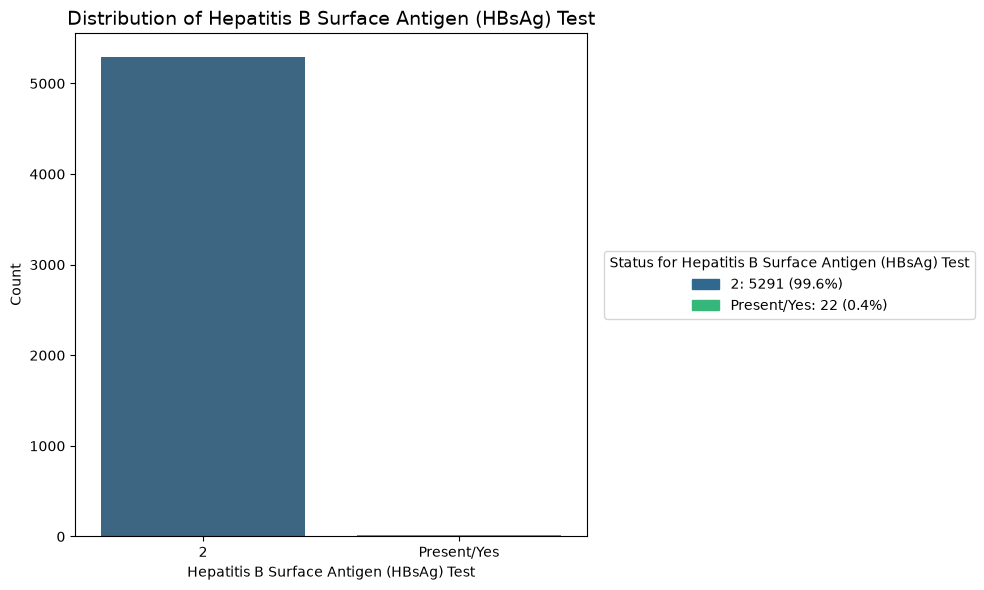

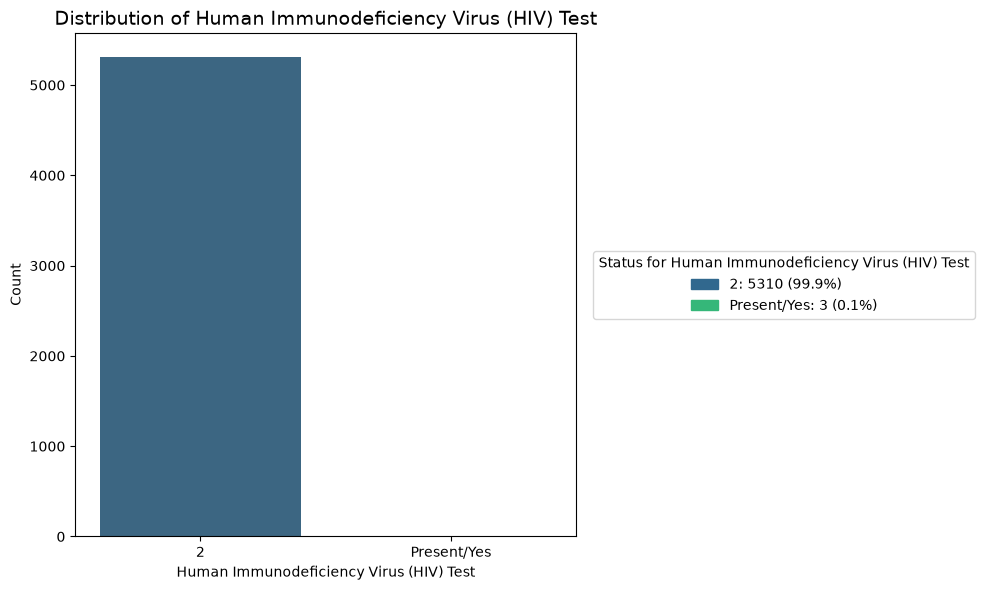

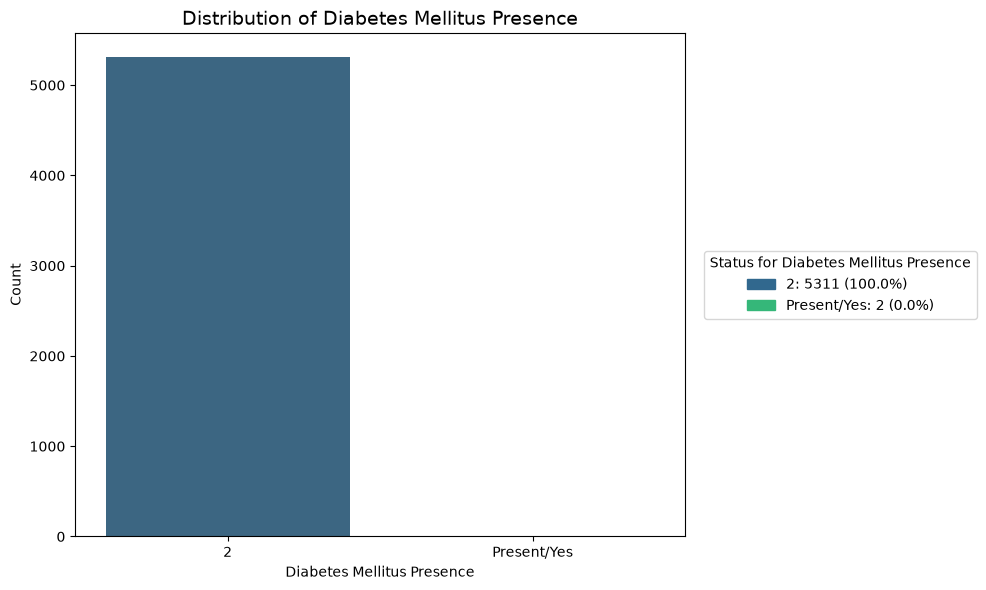

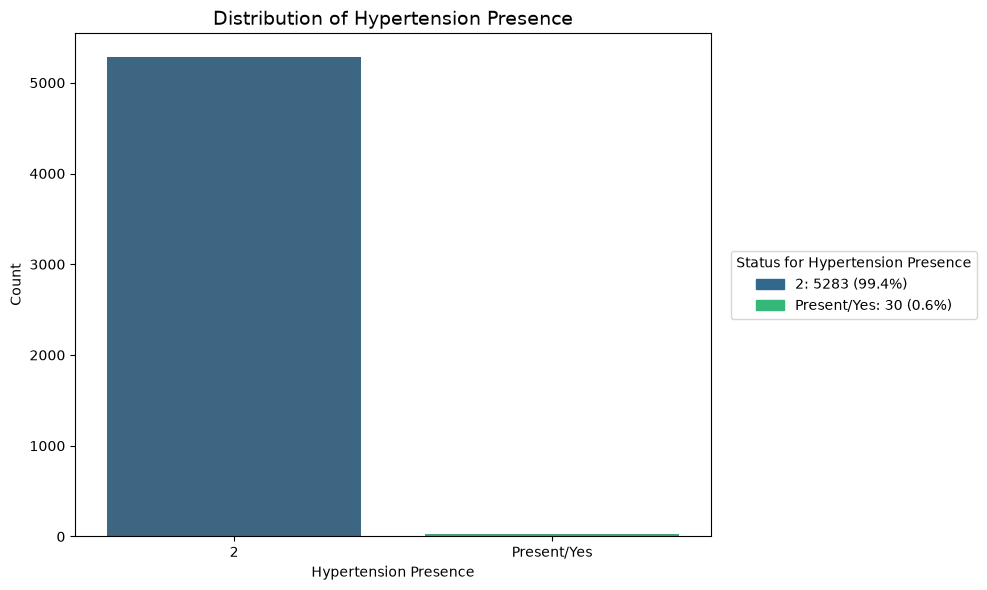

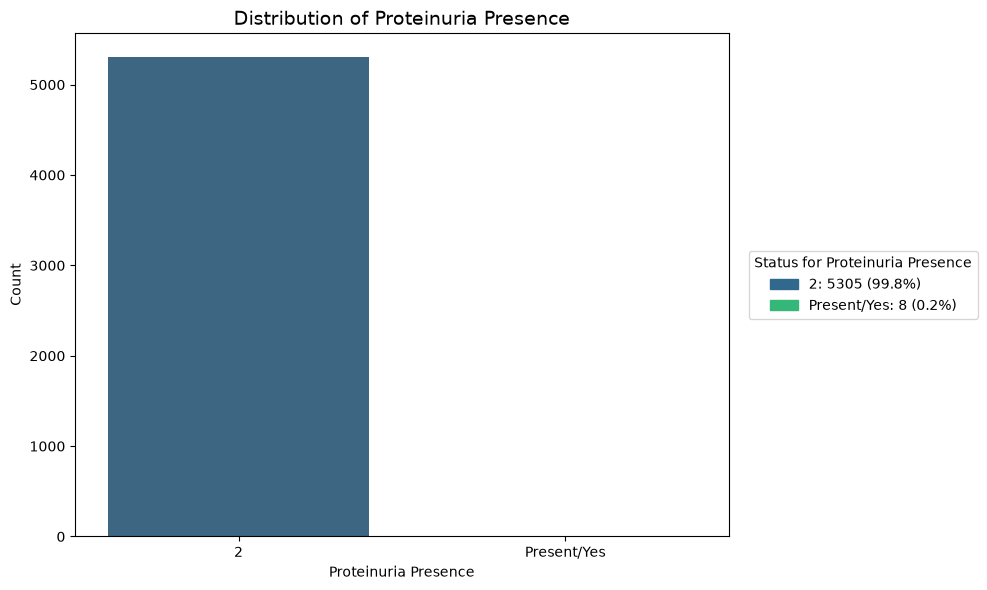

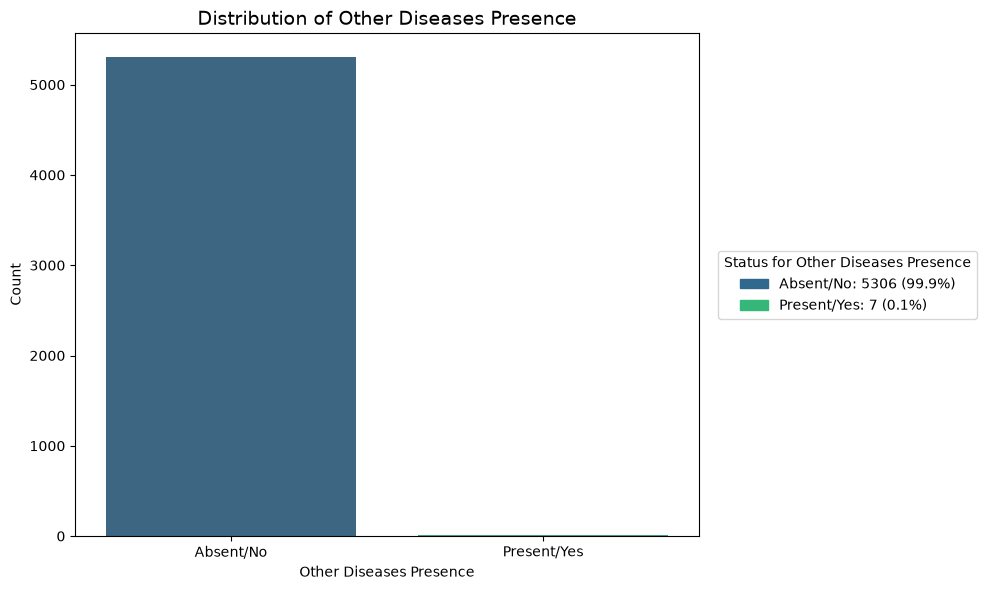

In [ ]:
# Redefine binary_cols to ensure it's available
numeric_cols, categorical_cols, binary_cols = detect_columns(df)

# Define a dictionary for more descriptive column titles


# Define mapping for binary categories to make them more readable


for col in binary_cols:
    fig, ax = plt.subplots(figsize=(10, 6))

    # Create a temporary series with descriptive labels for plotting
    plot_data =

    # Plot the count plot, allowing Seaborn to generate a legend
    sns.countplot(x=plot_data, hue=plot_data, ax=ax, palette='viridis')

    # Calculate counts and percentages for legend using the descriptive labels
    descriptive_value_counts = plot_data.value_counts()
    total = len(df[col])

    # Get the number of unique categories to determine the number of colors needed from the palette.
    num_categories = len(descriptive_value_counts)
    palette_colors = sns.color_palette('viridis', n_colors=num_categories)

    # Ensure labels_raw and descriptive_value_counts are in the same order
    # Sort categories to match the likely order of palette colors and plot bars
    sorted_categories = sorted(descriptive_value_counts.index.tolist())

    from matplotlib.patches import Patch
    new_handles = []
    new_legend_labels = []

    for i, label_str in enumerate(sorted_categories):
        count = descriptive_value_counts.get(label_str, 0)
        percentage = (count / total) * 100 if total > 0 else 0
        new_handles.append(Patch(color=palette_colors[i])) # Create a patch with the assigned color
        new_legend_labels.append(f'{label_str}: {count} ({percentage:.1f}%)')

    # Get descriptive title from dictionary, or use column name as fallback
    title = column_titles.get(col, col) # Fallback to original column name
    ax.set_title(f'Distribution of {title}', fontsize=14)
    ax.set_xlabel(title) # Use descriptive title for x-axis label as well
    ax.set_ylabel('Count')

    # Update the legend with new handles and labels, and reposition it to the side corner
    ax.legend(new_handles, new_legend_labels, title=f"Status for {title}", loc='center left', bbox_to_anchor=(1.02, 0.5))

    plt.tight_layout()
    plt.show()
    plt.close(fig)

#  Bivarient analysis

In [34]:
cols=df.drop("risiko_cat", axis=1).columns.to_list()

In [35]:
numeric_cols

['umur',
 'paritas',
 'jarak_anak',
 'jarak_anak_cat',
 'tb',
 'hb',
 'lila',
 'diastole',
 'sistole',
 'perdarahan']

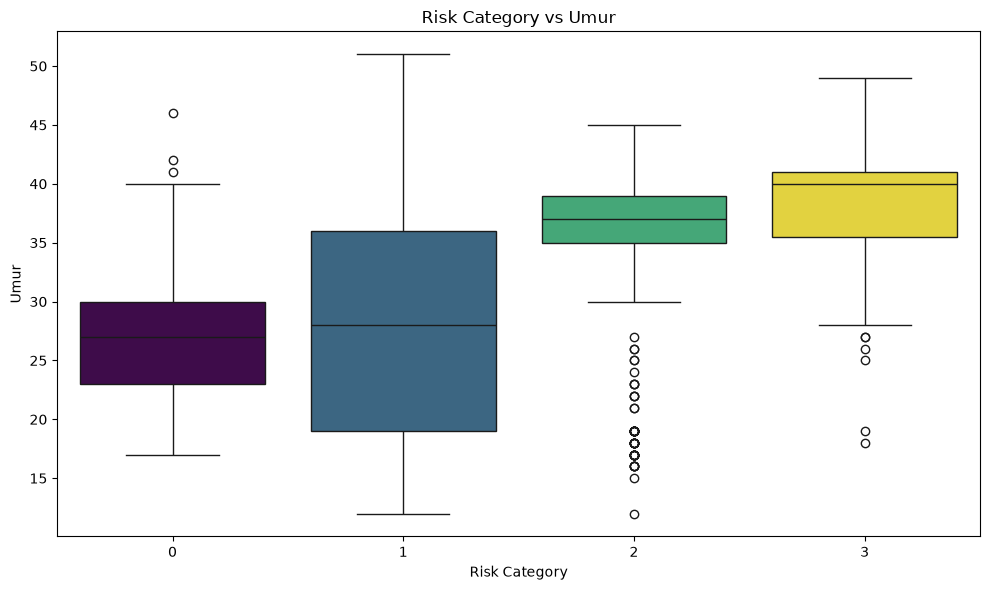

In [36]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(x="risiko_cat", y="umur", data=df, ax=ax, palette='viridis', hue="risiko_cat", legend=False)
ax.set_title("Risk Category vs Umur")
ax.set_xlabel("Risk Category")
ax.set_ylabel("Umur")
plt.tight_layout()
plt.show()

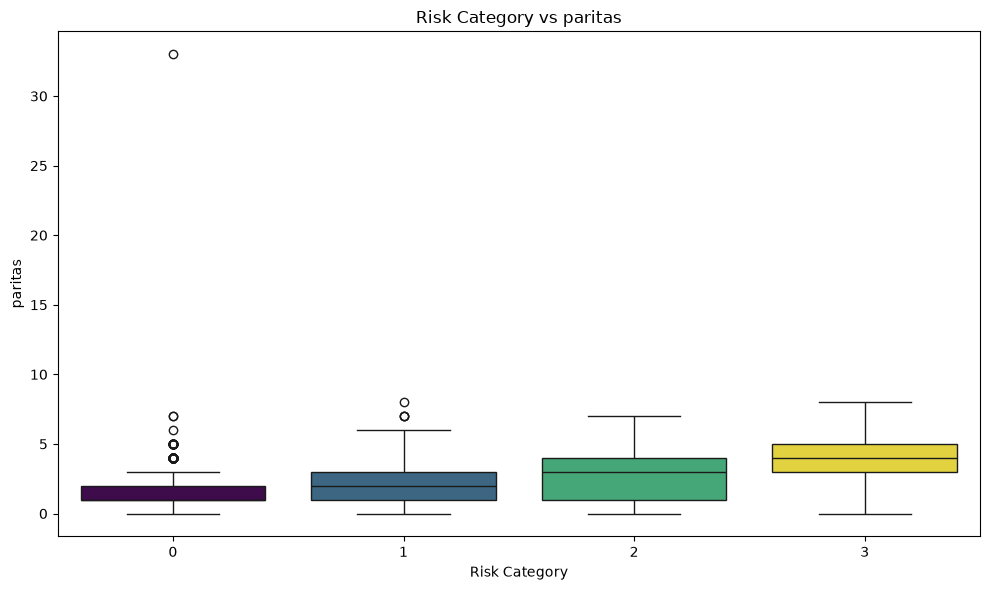

In [37]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(x="risiko_cat", y="paritas", data=df, ax=ax, palette='viridis', hue="risiko_cat", legend=False)
ax.set_title("Risk Category vs paritas")
ax.set_xlabel("Risk Category")
ax.set_ylabel("paritas")
plt.tight_layout()
plt.show()

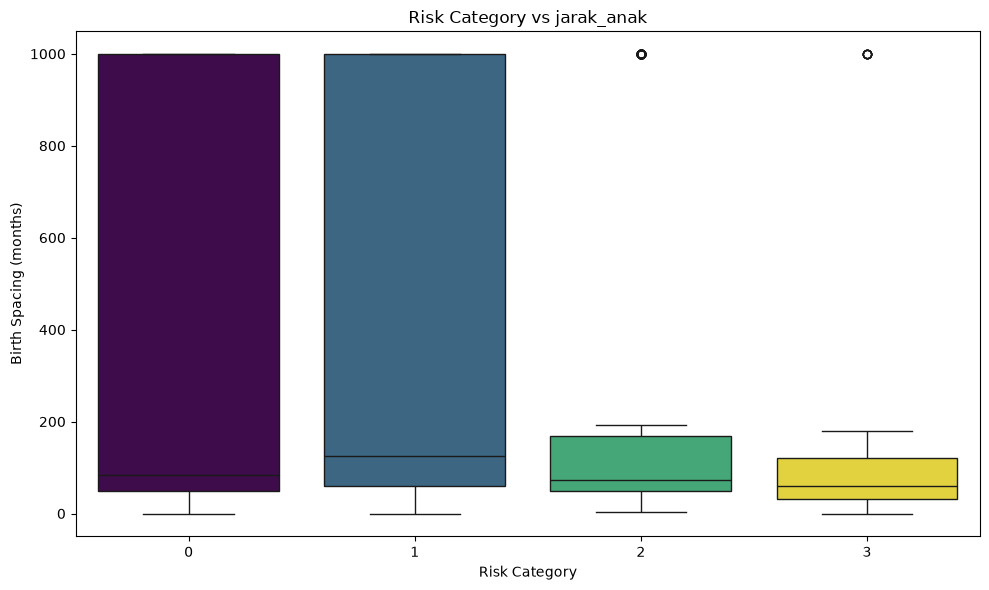

In [38]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(x="risiko_cat", y="jarak_anak", data=df, ax=ax, palette='viridis', hue="risiko_cat", legend=False)
ax.set_title("Risk Category vs jarak_anak")
ax.set_xlabel("Risk Category")
ax.set_ylabel("Birth Spacing (months)")
plt.tight_layout()
plt.show()

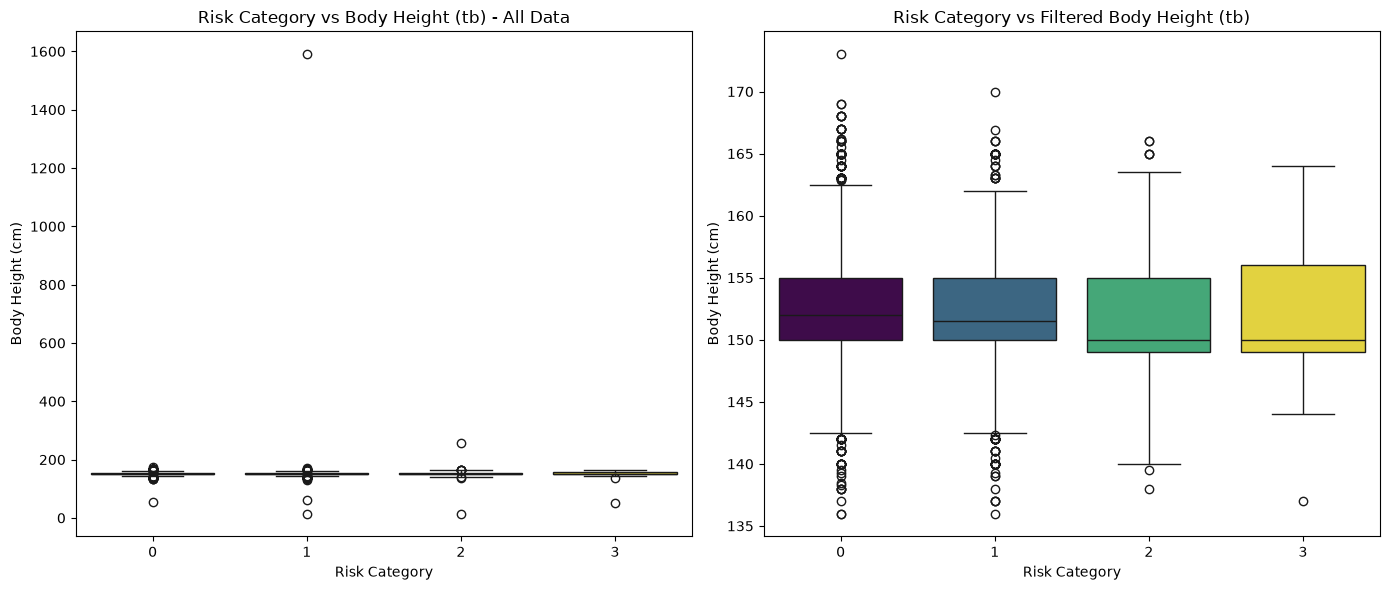

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(x="risiko_cat", y="tb", data=df, ax=axes[0], palette='viridis', hue="risiko_cat", legend=False)
axes[0].set_title('Risk Category vs Body Height (tb) - All Data')
axes[0].set_xlabel('Risk Category')
axes[0].set_ylabel('Body Height (cm)')

filtered_df = df[(df["tb"] < 180) & (df['tb'] > 135)]
sns.boxplot(x="risiko_cat", y="tb", data=filtered_df, ax=axes[1], palette='viridis', hue="risiko_cat", legend=False)
axes[1].set_title('Risk Category vs Filtered Body Height (tb)')
axes[1].set_xlabel('Risk Category')
axes[1].set_ylabel('Body Height (cm)')

plt.tight_layout()
plt.show()

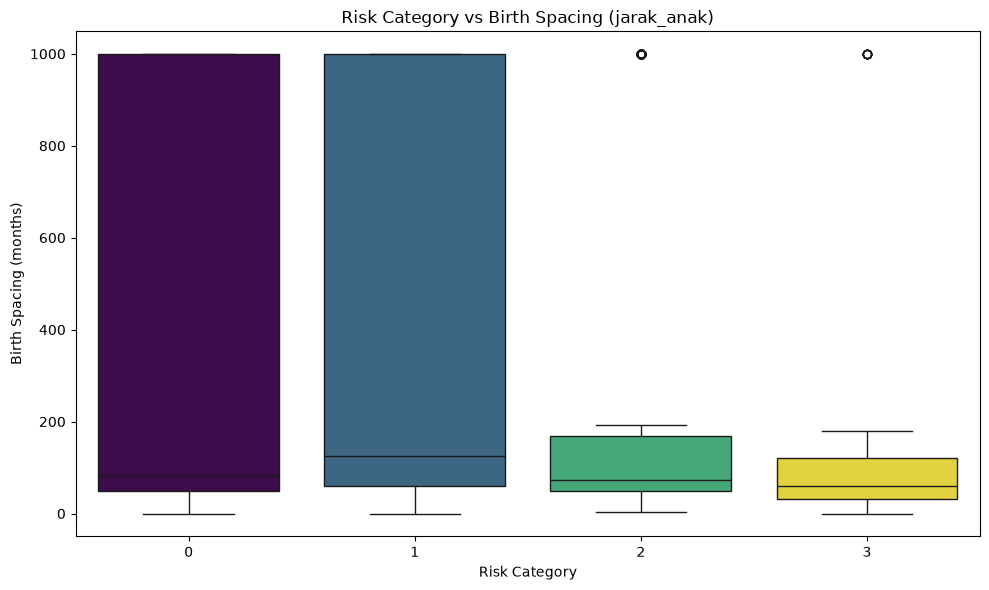

In [40]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x="risiko_cat", y="jarak_anak", data=df, ax=ax, palette='viridis', hue="risiko_cat", legend=False)
plt.title("Risk Category vs Birth Spacing (jarak_anak)")
plt.xlabel("Risk Category")
plt.ylabel("Birth Spacing (months)")
plt.tight_layout()
plt.show()

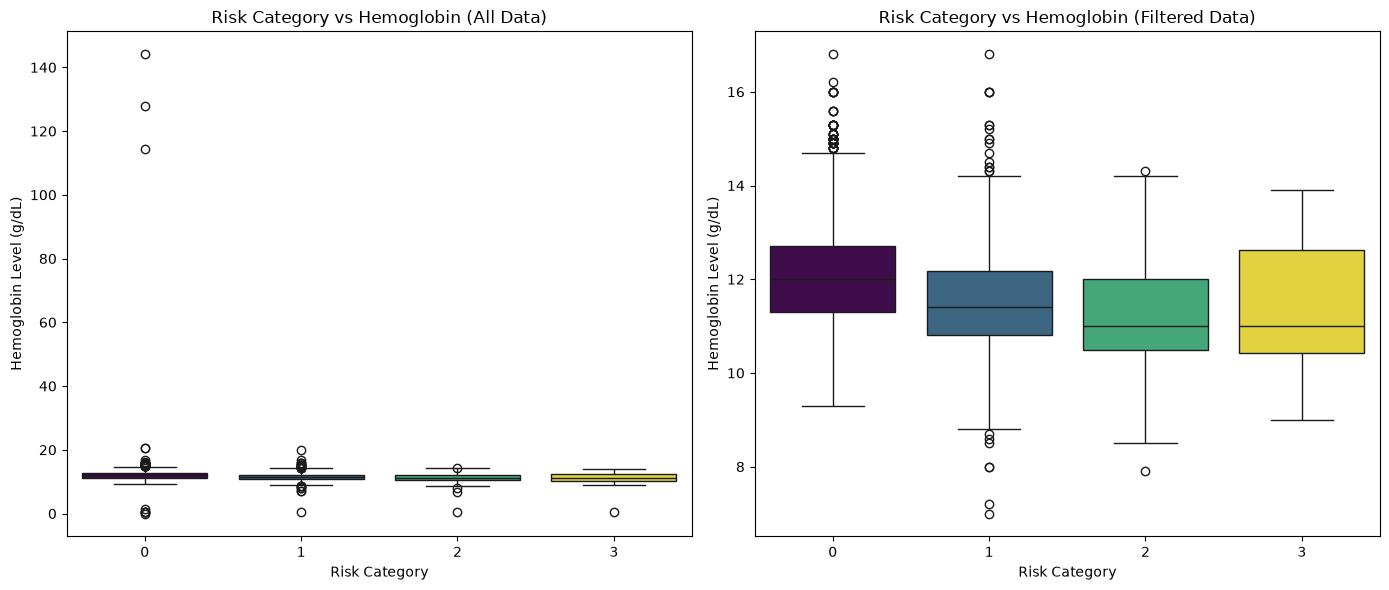

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# First box plot (all data)
sns.boxplot(x="risiko_cat", y="hb", data=df, ax=axes[0], palette='viridis', hue="risiko_cat", legend=False)
axes[0].set_title("Risk Category vs Hemoglobin (All Data)")
axes[0].set_xlabel("Risk Category")
axes[0].set_ylabel("Hemoglobin Level (g/dL)")

# Filtered data for the second box plot
filtered_df_hb = df[(df["hb"] < 18) & (df['hb'] >= 7)]
sns.boxplot(x="risiko_cat", y="hb", data=filtered_df_hb, ax=axes[1], palette='viridis', hue="risiko_cat", legend=False)
axes[1].set_title("Risk Category vs Hemoglobin (Filtered Data)")
axes[1].set_xlabel("Risk Category")
axes[1].set_ylabel("Hemoglobin Level (g/dL)")

plt.tight_layout()
plt.show()

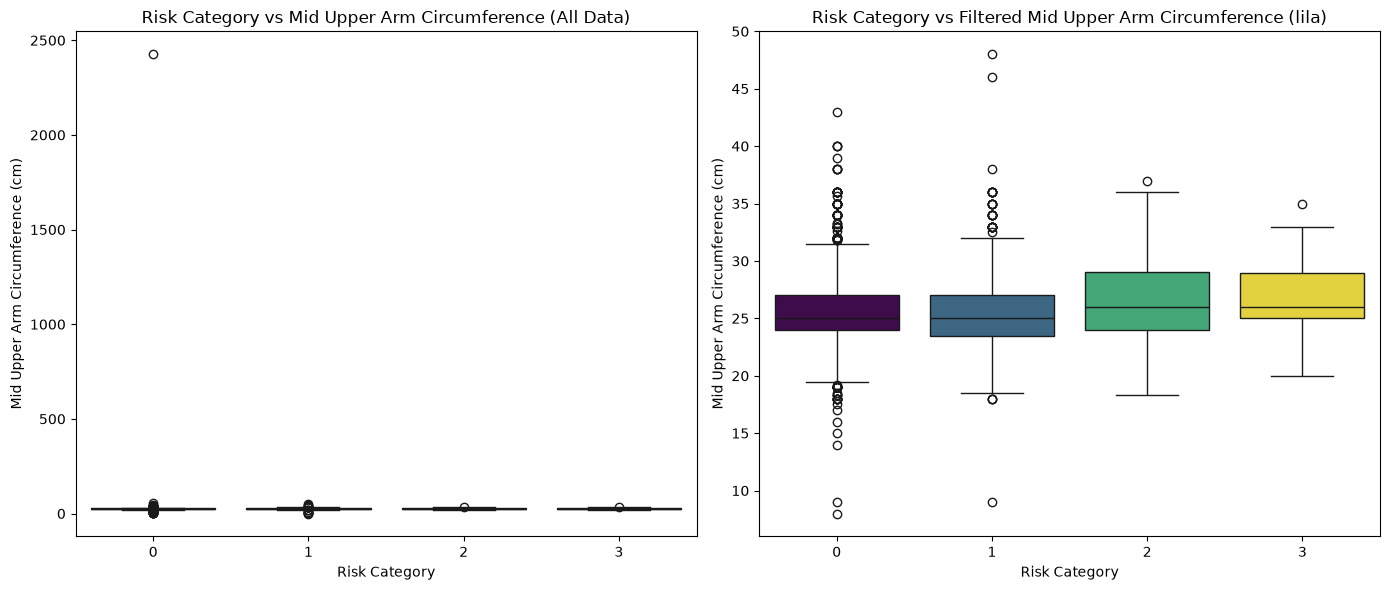

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# First box plot (all data)
sns.boxplot(x="risiko_cat", y="lila", data=df, ax=axes[0], palette='viridis', hue="risiko_cat", legend=False)
axes[0].set_title("Risk Category vs Mid Upper Arm Circumference (All Data)")
axes[0].set_xlabel("Risk Category")
axes[0].set_ylabel("Mid Upper Arm Circumference (cm)")

# Filtered data for the second box plot
filtered_df_lila = df[(df["lila"] < 50) & (df['lila'] >= 8)]
sns.boxplot(x="risiko_cat", y="lila", data=filtered_df_lila, ax=axes[1], palette='viridis', hue="risiko_cat", legend=False)
axes[1].set_title("Risk Category vs Filtered Mid Upper Arm Circumference (lila)")
axes[1].set_xlabel("Risk Category")
axes[1].set_ylabel("Mid Upper Arm Circumference (cm)")

plt.tight_layout()
plt.show()

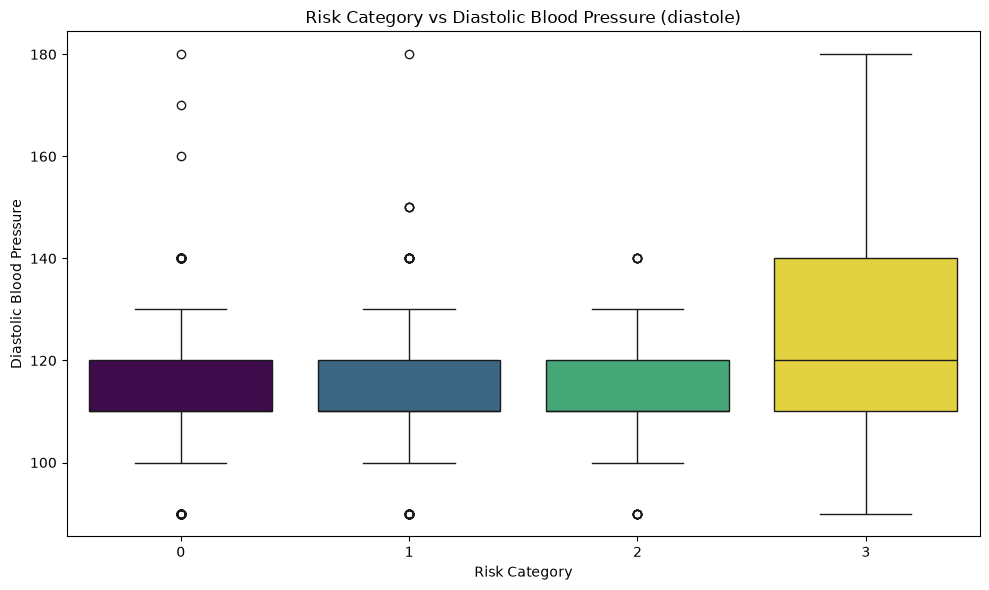

In [43]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x="risiko_cat", y="diastole", data=df, ax=ax, palette='viridis', hue="risiko_cat", legend=False)
plt.title("Risk Category vs Diastolic Blood Pressure (diastole)")
plt.xlabel("Risk Category")
plt.ylabel("Diastolic Blood Pressure")
plt.tight_layout()
plt.show()

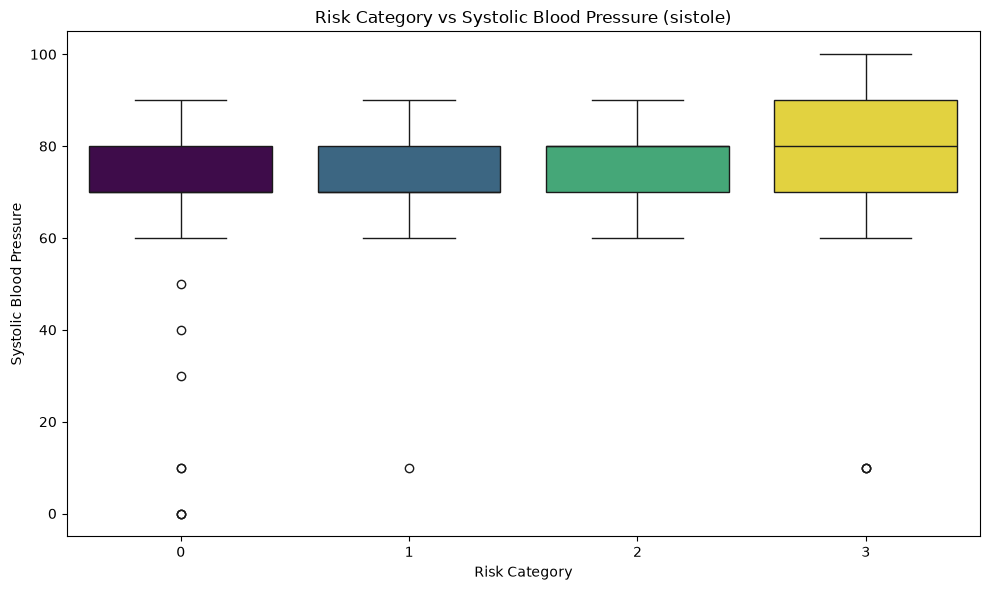

In [44]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x="risiko_cat", y="sistole", data=df, ax=ax, palette='viridis', hue="risiko_cat", legend=False)
plt.title("Risk Category vs Systolic Blood Pressure (sistole)")
plt.xlabel("Risk Category")
plt.ylabel("Systolic Blood Pressure")
plt.tight_layout()
plt.show()

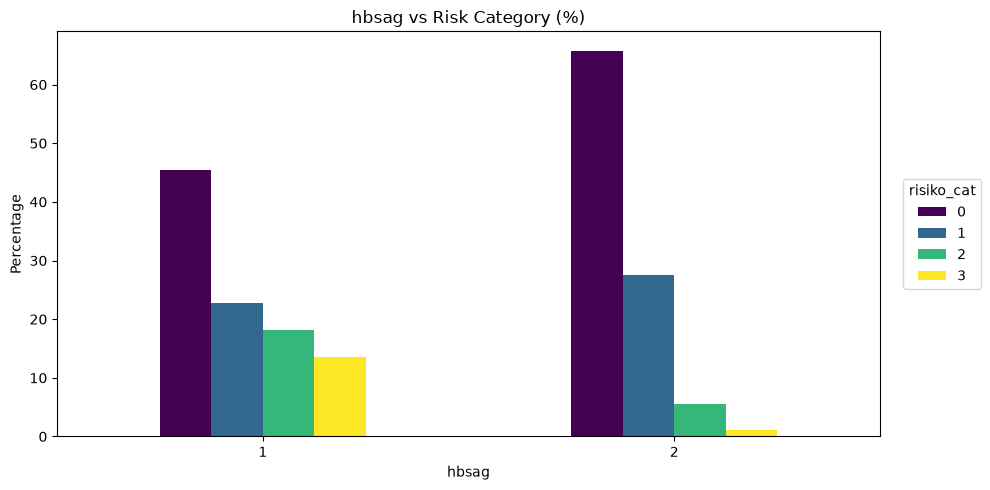

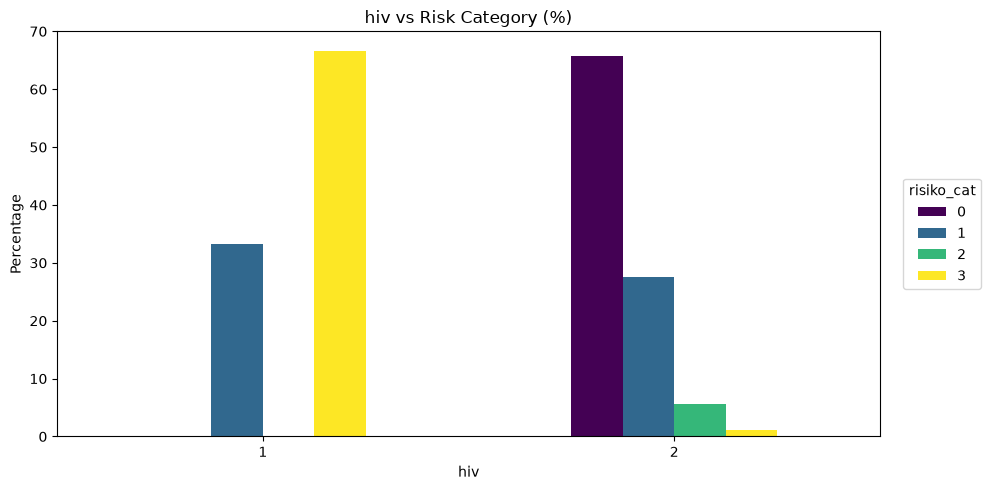

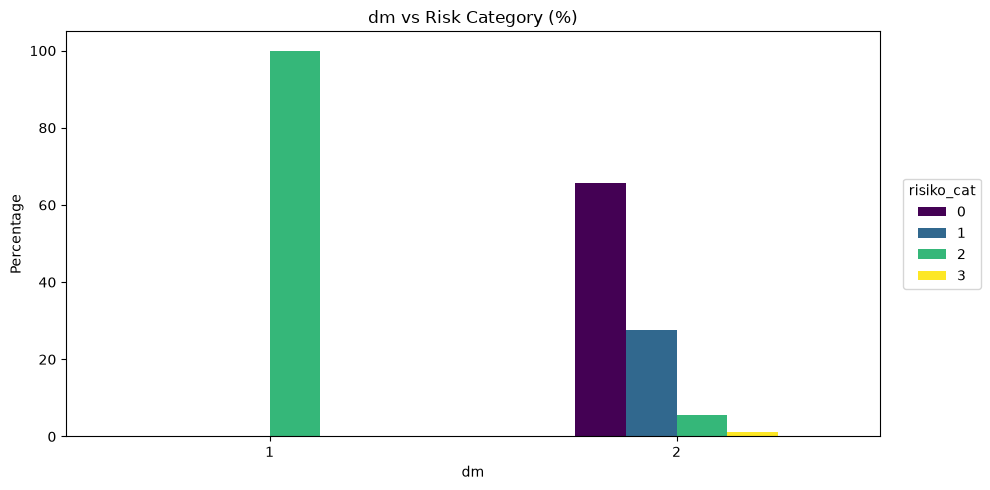

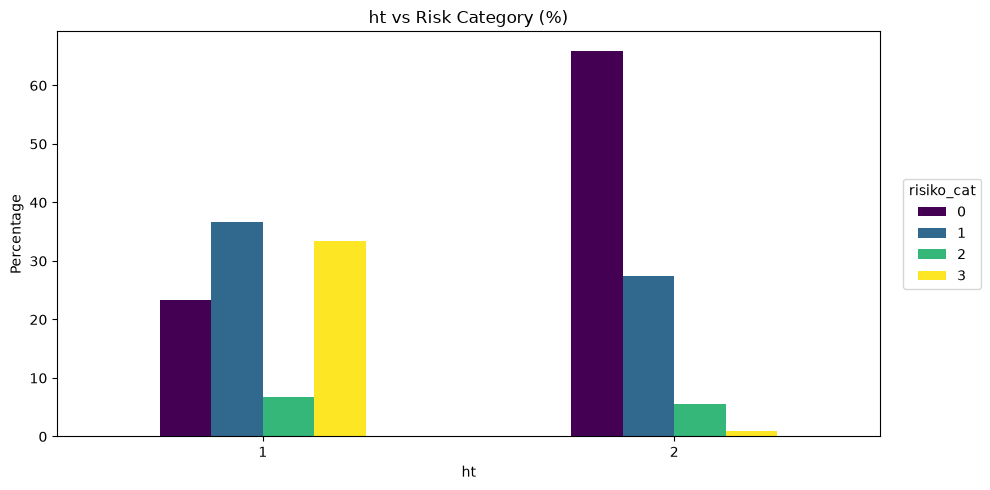

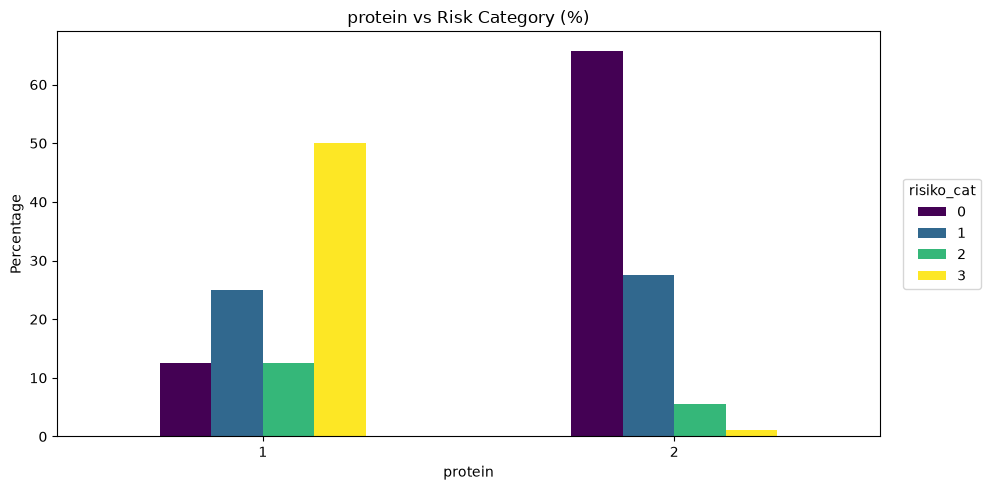

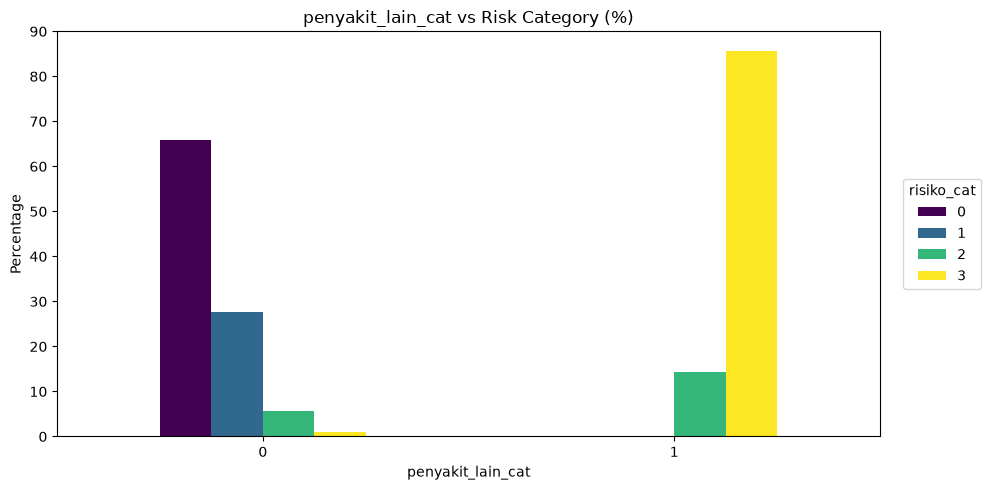

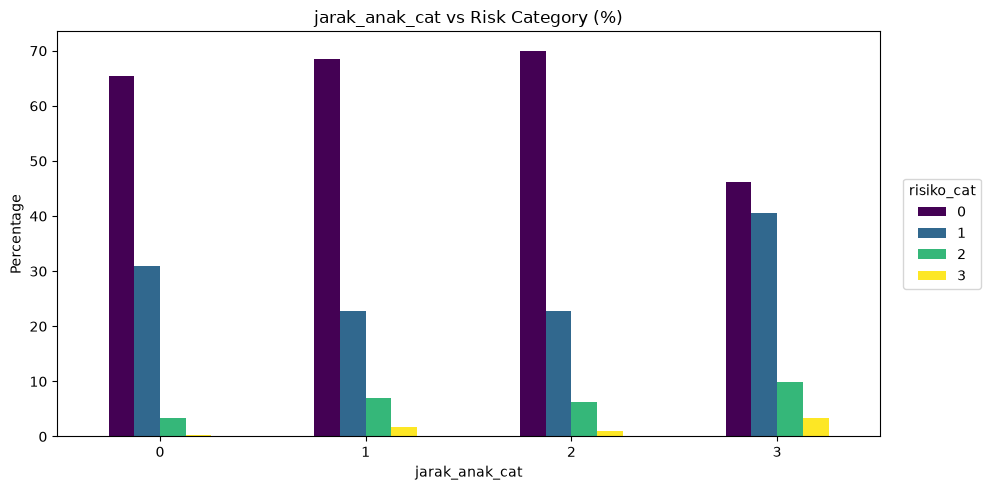

In [45]:
for col in binary_cols + ['jarak_anak_cat']:
    ct = pd.crosstab(df[col], df['risiko_cat'], normalize='index') * 100
    ct.plot(kind='bar', figsize=(10, 5), colormap='viridis')
    plt.title(f"{col} vs Risk Category (%)")
    plt.ylabel("Percentage")
    plt.xticks(rotation=0)
    plt.legend(title='risiko_cat', bbox_to_anchor=(1.02, 0.5), loc='center left')
    plt.tight_layout()
    plt.show()

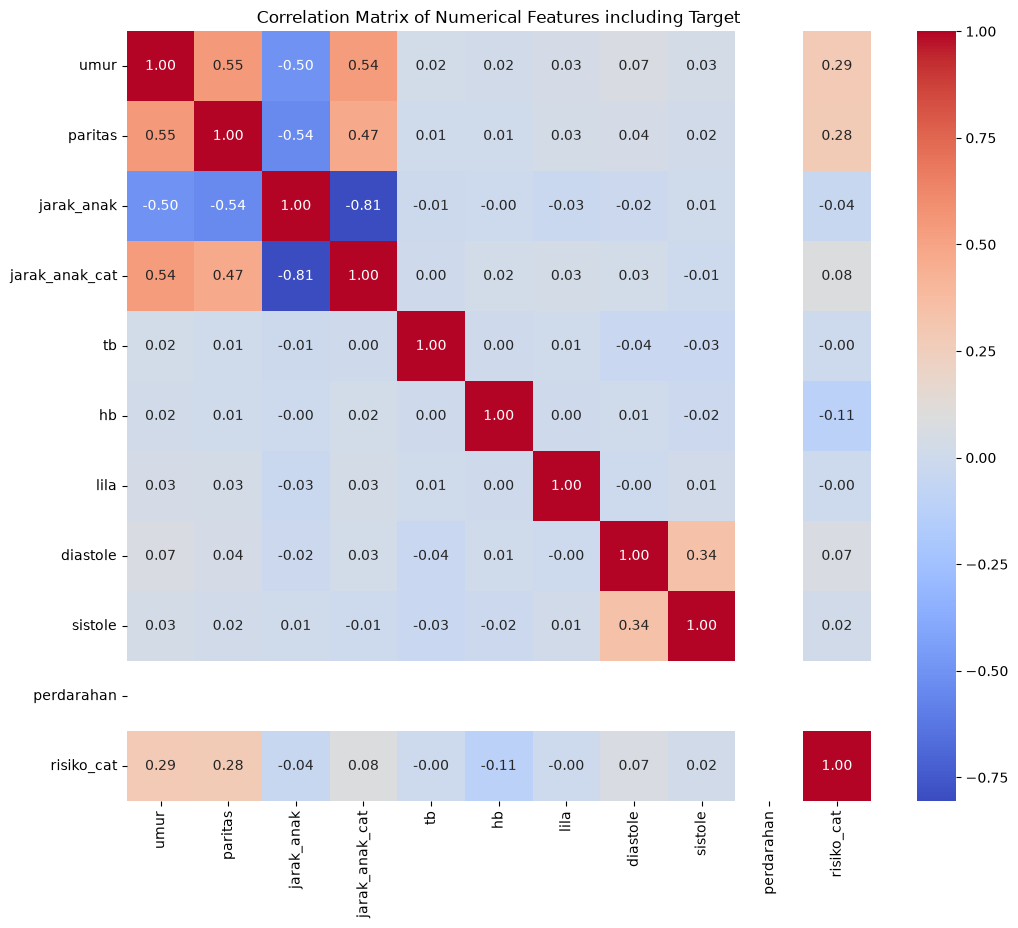

In [46]:
plt.figure(figsize=(12, 10))
# Create a list of all relevant columns for the heatmap, including the target
heatmap_cols = numeric_cols + [terget]
sns.heatmap(df[heatmap_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features including Target')
plt.show()

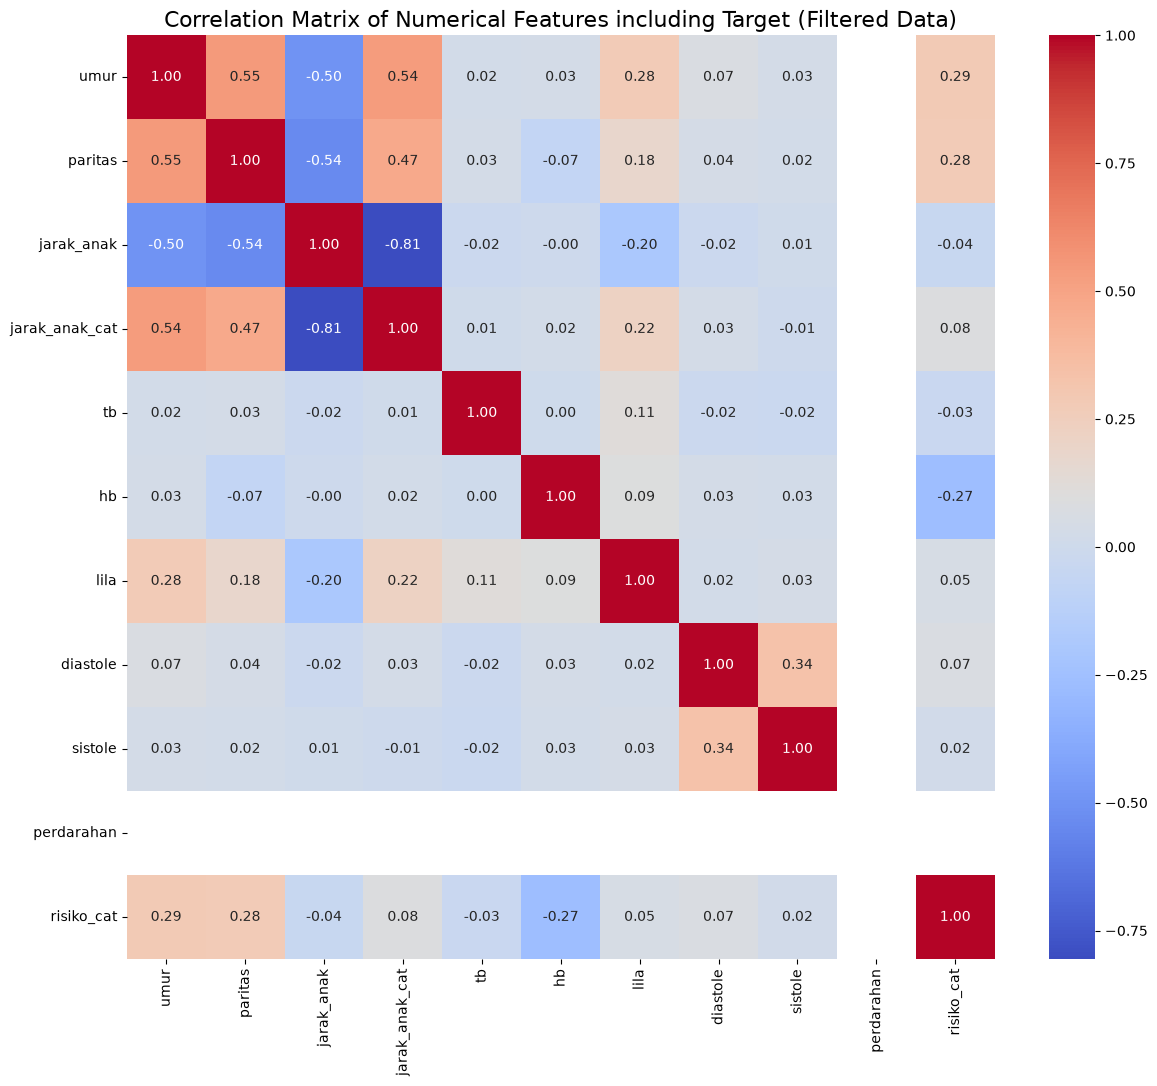

In [47]:
plt.figure(figsize=(14, 12))

# Combine all filtering conditions from previous analysis
combined_filtered_df = df[
    (df["tb"] < 170) & (df['tb'] > 130) &
    (df["hb"] < 18) & (df['hb'] >= 7) &
    (df["lila"] < 50) & (df['lila'] >= 8)
]

# Define columns for heatmap including the target
# Assuming 'numeric_cols' and 'terget' are already defined in the session
heatmap_cols_filtered = numeric_cols + [terget]

sns.heatmap(combined_filtered_df[heatmap_cols_filtered].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features including Target (Filtered Data)', fontsize=16)
plt.show()

In [48]:
df_filtered = combined_filtered_df.copy()
print(f"Shape of the filtered DataFrame: {df_filtered.shape}")
print("Head of the filtered DataFrame:")
df_filtered.head(3)

Shape of the filtered DataFrame: (5273, 17)
Head of the filtered DataFrame:


,umur,paritas,jarak_anak,jarak_anak_cat,tb,hb,lila,hbsag,hiv,dm,ht,protein,diastole,sistole,perdarahan,penyakit_lain_cat,risiko_cat
0,20,0,999.0,0,150.0,9.6,24.0,2,2,2,2,2,120,90,2,0,1
1,30,3,48.0,1,151.0,11.2,28.0,2,2,2,2,2,120,80,2,0,0
2,28,1,77.0,2,150.0,12.3,26.0,2,2,2,2,2,110,70,2,0,0


In [49]:
df_filtered.to_csv('pregnancy_risk_filtered.csv', index=False)

The filtered dataset has been successfully saved to `pregnancy_risk_filtered.csv`.